# Pipeline TCC — Perfil STEM no ENEM 2018–2023
**Estrutura:** 4 definições de target × 4 modelos = 16 combinações  
**Etapas:** Pré-processamento → Baseline → Comparação 1 → Tuning → Comparação final → SHAP  

> **Dependências:** `pip install xgboost lightgbm catboost optuna shap`


In [ ]:
# ── 1. Imports e Configurações Iniciais ─────────────────────────────────────

# --- Bibliotecas Padrão ---
import os
import gc
import time
import warnings

# --- Manipulação de Dados ---
import numpy as np
import pandas as pd

# --- Visualização e Interpretabilidade ---
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import shap

# --- Machine Learning: Pré-processamento e Métricas ---
from sklearn.model_selection import (
    train_test_split, 
    StratifiedKFold, 
    StratifiedShuffleSplit
)
from sklearn.metrics import (
    roc_auc_score, f1_score, precision_score, recall_score,
    roc_curve, ConfusionMatrixDisplay, RocCurveDisplay
)

# --- Machine Learning: Modelos ---
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# --- Otimização de Hiperparâmetros ---
import optuna
from optuna.pruners import MedianPruner

# --- Persistência de Modelos ---
import joblib

# ── 1.1 Configurações Globais do Ambiente ───────────────────────────────────

# Ignora alertas não críticos para manter o console limpo
warnings.filterwarnings("ignore")

# Reduzir a verbosidade do Optuna (mostra apenas avisos/erros, omitindo logs de cada trial)
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Cria o diretório 'resultados' caso ele não exista
os.makedirs("resultados", exist_ok=True)

# Inicializa o JavaScript necessário para carregar os gráficos do SHAP no Jupyter/Colab
shap.initjs()

print("✅ Imports e configurações carregados com sucesso!")

Imports OK


## 2. Carregamento dos dados

In [ ]:
# ── 2. Carregamento ─────────────────────────────────────────────────────────
# --- Carrega os dados de 2018 a 2023, exibindo o formato do dataset, os anos da tabela e as 3 primeiras linhas dela

CAMINHO = r"C:\Users\Claudia\Documents\TCC\data\processed\DATASET_MASTER_ENEM_2018_2023.parquet"
df = pd.read_parquet(CAMINHO)

print(f"Shape: {df.shape[0]:,} linhas × {df.shape[1]} colunas")
print(f"Anos: {sorted(df['ANO'].unique())}")
df.head(3)


Shape: 14,705,081 linhas × 22 colunas
Anos: [np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023)]


,TP_FAIXA_ETARIA,NU_NOTA_CN,NU_NOTA_MT,IN_FEMININO,RACA_AMARELA,RACA_BRANCA,RACA_INDIGENA,RACA_NAO_DECLARADO,RACA_PARDA,RACA_PRETA,...,REGIAO_CENTRO_OESTE,REGIAO_NORDESTE,REGIAO_NORTE,REGIAO_SUDESTE,REGIAO_SUL,ESC_PAI,ESC_MAE,TEM_INTERNET,RENDA_FAMILIAR,ANO
0,2,534.2,496.3,1,1,0,0,0,0,0,...,0,0,1,0,0,4,4,1,5,2018
1,3,506.9,440.6,1,1,0,0,0,0,0,...,0,0,1,0,0,3,4,0,1,2018
2,3,470.6,410.4,0,0,0,0,1,0,0,...,0,0,0,1,0,1,1,0,1,2018


## 3. Definição dos targets (mediana calculada por ano)

In [ ]:
# ── 3. Targets ──────────────────────────────────────────────────────────────
# Mediana calculada dentro de cada ano
df["MED_MT"] = df.groupby("ANO")["NU_NOTA_MT"].transform("median")
df["MED_CN"] = df.groupby("ANO")["NU_NOTA_CN"].transform("median")

# Definição dos targets para o "Perfil STEM"
TARGETS = {
    # --- T1 - Participantes com nota acima da mediana de Matemática --- 
    "T1_so_MT":    (df["NU_NOTA_MT"] >= df["MED_MT"]).astype(int), 
    # --- T2 - Participantes com nota acima da mediana de Matemática ou Ciências da Natureza ---
    "T2_MT_ou_CN": ((df["NU_NOTA_MT"] >= df["MED_MT"]) | (df["NU_NOTA_CN"] >= df["MED_CN"])).astype(int),
    # --- T3 - Participantes com nota acima da mediana de Matemática e Ciências da Natureza ---
    "T3_MT_e_CN":  ((df["NU_NOTA_MT"] >= df["MED_MT"]) & (df["NU_NOTA_CN"] >= df["MED_CN"])).astype(int),
    # --- T4 - Participantes com nota acima da mediana de Ciências da Natureza ---
    "T4_so_CN":    (df["NU_NOTA_CN"] >= df["MED_CN"]).astype(int),
}

# Balanceamento (mostra o quanto os targets definidos estão presentes no dataset em relação a população)
resumo = pd.DataFrame({
    "Positivos (%)": {k: f"{v.mean()*100:.1f}%" for k, v in TARGETS.items()},
    "N positivos":   {k: int(v.sum())            for k, v in TARGETS.items()},
    "N negativos":   {k: int((v==0).sum())       for k, v in TARGETS.items()},
})
print(resumo.to_string())


            Positivos (%)  N positivos  N negativos
T1_so_MT            50.0%      7354994      7350087
T2_MT_ou_CN         64.8%      9525314      5179767
T3_MT_e_CN          35.3%      5184931      9520150
T4_so_CN            50.0%      7355251      7349830


## 4. Preparação das features

In [ ]:
# ── 4. Features ─────────────────────────────────────────────────────────────
COLS_REMOVER = ["NU_NOTA_MT", "NU_NOTA_CN", "MED_MT", "MED_CN"] 
X = df.drop(columns=COLS_REMOVER) # Remove os targets para evitar vazamento de dados

# Identifica colunas categóricas (usado pelo CatBoost)
CAT_COLS  = [c for c in X.columns if X[c].dtype == "object" or str(X[c].dtype) == "category"]
CAT_IDX   = [X.columns.get_loc(c) for c in CAT_COLS]

print(f"Features totais : {X.shape[1]}")
print(f"Categóricas     : {len(CAT_COLS)}")
print(f"Numéricas       : {X.shape[1] - len(CAT_COLS)}")


Features totais : 20
Categóricas     : 0
Numéricas       : 20


## 5. Modelos baseline

In [ ]:
# ── 5. Modelos Baseline ─────────────────────────────────────────────────────

def get_modelos():
    """
    Gera e retorna um dicionário com os modelos de machine learning configurados 
    com hiperparâmetros de baseline (linha de base).

    Estes modelos iniciais servem como ponto de partida para avaliação de 
    performance antes da etapa de otimização (tuning com Optuna). Eles já 
    incluem configurações para lidar com desbalanceamento de classes e 
    fixação de sementes aleatórias para garantir a reprodutibilidade.

    Note:
        A variável global 'CAT_IDX' deve estar previamente definida no escopo 
        para que o CatBoost identifique as colunas categóricas nativamente.

    Returns:
        dict: Dicionário onde as chaves são os nomes dos algoritmos (str) e 
              os valores são as instâncias dos classificadores configurados.
    """
    return {
        # Random Forest: Resistente a outliers e bom para estabelecer uma base sólida.
        # class_weight="balanced" ajusta os pesos se as classes forem desproporcionais.
        "RandomForest": RandomForestClassifier(
            n_estimators=100, max_depth=15, min_samples_split=50,
            class_weight="balanced", n_jobs=-1, random_state=42,
        ),
        
        # XGBoost: Gradient Boosting clássico, altamente otimizado.
        # reg_alpha e reg_lambda aplicam regularização L1/L2 para evitar overfitting inicial.
        "XGBoost": XGBClassifier(
            n_estimators=200, max_depth=6, learning_rate=0.1,
            reg_alpha=0.1, reg_lambda=1.0, eval_metric="logloss",
            n_jobs=-1, random_state=42, verbosity=0,
        ),
        
        # LightGBM: Focado em velocidade e eficiência no uso de memória (Leaf-wise).
        # num_leaves controla a complexidade da árvore; verbose=-1 silencia os logs.
        "LightGBM": LGBMClassifier(
            n_estimators=200, num_leaves=63, learning_rate=0.1,
            min_child_samples=50, class_weight="balanced",
            n_jobs=-1, random_state=42, verbose=-1,
        ),
        
        # CatBoost: Excelente performance sem precisar de muito pré-processamento.
        # auto_class_weights="Balanced" lida automaticamente com o desbalanceamento.
        "CatBoost": CatBoostClassifier(
            iterations=200, depth=6, learning_rate=0.1, l2_leaf_reg=3,
            auto_class_weights="Balanced",
            cat_features=CAT_IDX if CAT_IDX else None,
            random_seed=42, verbose=0,
        ),
    }

# --- Constantes de Iteração ---
# Lista para facilitar os loops de treinamento ao percorrer o dicionário gerado
NOMES_MODELOS = ["RandomForest", "XGBoost", "LightGBM", "CatBoost"]

# Extrai as chaves do dicionário TARGETS global para iterar sobre as variáveis dependentes
NOMES_TARGETS = list(TARGETS.keys())

## 6. Loop principal — 16 combinações

In [ ]:
# ── 6. Loop Principal de Treinamento (Baseline) ─────────────────────────────
"""
Este bloco itera sobre todos as targets definidas e treina os modelos 
baseline para cada um, avaliando a performance inicial de cada combinação.

A separação dos dados (train_test_split) é feita individualmente por target de 
forma estratificada. Isso garante que a proporção original das classes seja 
mantida entre os conjuntos de treino e teste, um passo crítico para evitar 
vieses em bases de dados desbalanceadas.
"""

# --- Estruturas de Armazenamento ---
# Chaves em formato de tupla: (nome_do_target, nome_do_modelo)
resultados_baseline = {}   # Armazena as métricas calculadas e os vetores de predição
modelos_treinados   = {}   # Armazena os objetos dos modelos já ajustados (fitted)

# Chave em formato de string: nome_do_target
splits_por_target   = {}   # Armazena as fatias de dados: (X_train, X_test, y_train, y_test)


# --- Início do Loop ---
for nome_t, y in TARGETS.items():
    
    # 1. Divisão Estratificada dos Dados
    # test_size=0.2 reserva 20% para teste. stratify=y é chave para manter a proporção da variável resposta.
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    splits_por_target[nome_t] = (X_train, X_test, y_train, y_test)

    # Cabeçalho visual para o target atual no console
    print(f"\n{'─'*55}")
    print(f"  Target: {nome_t}")
    print(f"{'─'*55}")

    # 2. Treinamento e Avaliação por Modelo
    for nome_m, modelo in get_modelos().items():
        print(f"  {nome_m:<16}", end=" → ")
        
        # Treinamento do modelo
        modelo.fit(X_train, y_train)

        # Inferência (predições de classe e probabilidades contínuas)
        y_pred  = modelo.predict(X_test)
        y_proba = modelo.predict_proba(X_test)[:, 1] # Pega a probabilidade da classe positiva (1)

        # 3. Cálculo de métricas
        # zero_division=0 evita warnings caso o modelo preveja apenas uma classe
        metricas = dict(
            roc_auc   = roc_auc_score(y_test, y_proba),
            f1        = f1_score(y_test, y_pred, zero_division=0),
            precision = precision_score(y_test, y_pred, zero_division=0),
            recall    = recall_score(y_test, y_pred, zero_division=0),
            y_test    = y_test,
            y_pred    = y_pred,
            y_proba   = y_proba,
        )

        # 4. Salvamento dos Resultados
        resultados_baseline[(nome_t, nome_m)] = metricas
        modelos_treinados[(nome_t, nome_m)]   = modelo

        # Print dos resultados (formatados com 4 casas decimais para alinhamento)
        print(f"AUC={metricas['roc_auc']:.4f}  F1={metricas['f1']:.4f}  "
              f"P={metricas['precision']:.4f}  R={metricas['recall']:.4f}")

print("\n✅ Treinamento baseline Concluído!")



───────────────────────────────────────────────────────
  Target: T1_so_MT
───────────────────────────────────────────────────────
  RandomForest     → AUC=0.7460  F1=0.6702  P=0.6918  R=0.6500
  XGBoost          → AUC=0.7474  F1=0.6726  P=0.6908  R=0.6552
  LightGBM         → AUC=0.7475  F1=0.6726  P=0.6911  R=0.6550
  CatBoost         → AUC=0.7471  F1=0.6724  P=0.6909  R=0.6549

───────────────────────────────────────────────────────
  Target: T2_MT_ou_CN
───────────────────────────────────────────────────────
  RandomForest     → 

MemoryError: Unable to allocate 89.8 MiB for an array with shape (11764064,) and data type float64

## 7. Primeira comparação — heatmaps e curvas ROC

In [ ]:
# ── 7a. Tabelas de Resumo das Métricas ──────────────────────────────────────

def tabela_metrica(metrica_key):
    """
    Gera um DataFrame consolidado para uma métrica específica, cruzando os 
    modelos treinados com as variáveis target.

    A função extrai os valores do dicionário global 'resultados_baseline' 
    e constrói uma matriz onde as linhas representam os algoritmos e as 
    colunas representam os targets avaliados.

    Args:
        metrica_key (str): Chave exata da métrica salva no dicionário de 
            resultados (ex: 'roc_auc', 'f1', 'precision', 'recall').

    Returns:
        pandas.DataFrame: Tabela resumo com os valores numéricos da métrica 
            solicitada, arredondados para 4 casas decimais.
    """
    
    # Constrói uma matriz 2D (lista de listas):
    # Para cada modelo iterado (linha), extrai-se os valores de todos os targets (colunas)
    matriz_valores = [
        [resultados_baseline[(target, modelo)][metrica_key] for target in NOMES_TARGETS]
        for modelo in NOMES_MODELOS
    ]
    
    # Converte a matriz em DataFrame, aplicando os nomes nas linhas e colunas
    return pd.DataFrame(
        matriz_valores,
        index=NOMES_MODELOS,
        columns=NOMES_TARGETS,
    ).round(4)


# --- Geração e Exibição das Tabelas ---

# Extrai os DataFrames para as principais métricas de interesse
tab_auc = tabela_metrica("roc_auc")
tab_f1  = tabela_metrica("f1")

# Imprime os resultados formatados no console
print("🏆 Resumo ROC-AUC:")
print(tab_auc.to_string())
print("\n" + "═"*55 + "\n")
print("🎯 Resumo F1-Score:")
print(tab_f1.to_string())


ROC-AUC:
               T1_so_MT  T2_MT_ou_CN  T3_MT_e_CN  T4_so_CN
RandomForest    0.7460       0.7381      0.7689    0.7197
XGBoost         0.7474       0.7394      0.7704    0.7210
LightGBM        0.7475       0.7394      0.7705    0.7210
CatBoost        0.7471       0.7390      0.7702    0.7206 

F1-score:
               T1_so_MT  T2_MT_ou_CN  T3_MT_e_CN  T4_so_CN
RandomForest    0.6702       0.7072      0.6176    0.6444
XGBoost         0.6726       0.7864      0.5506    0.6460
LightGBM        0.6726       0.7086      0.6193    0.6459
CatBoost        0.6724       0.7091      0.6192    0.6453


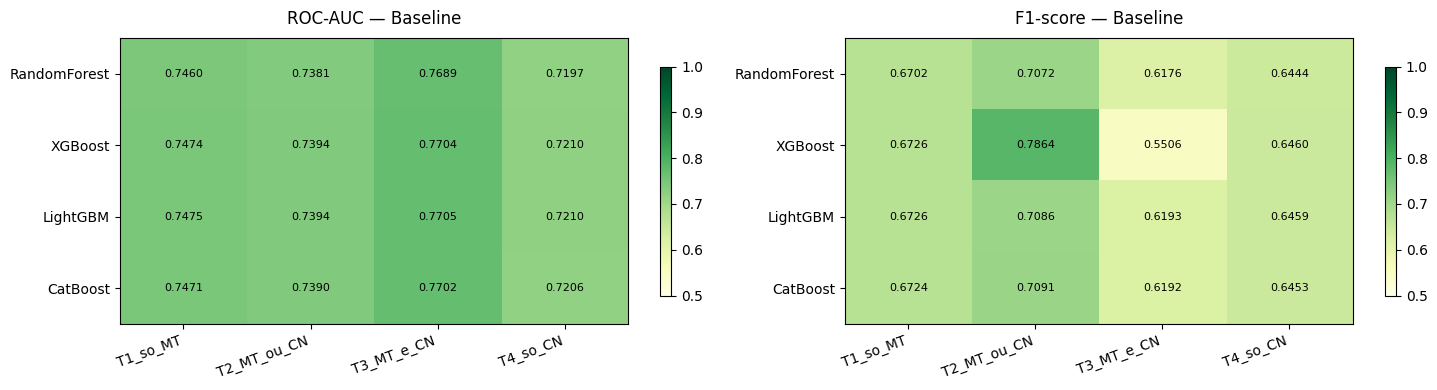

In [ ]:
# ── 7b. Visualização: gráficos de calor de performance (Baseline) ─────────

def plotar_heatmaps_baseline(tab_auc, tab_f1):
    """
    Gera e salva heatmaps comparativos para as métricas ROC-AUC e F1-score 
    dos modelos de baseline treinados no dataset principal.

    Utiliza o Seaborn para criar uma visualização estética, limpa e padronizada.
    As cores são calculadas dinamicamente para cada métrica, garantindo que o 
    contraste visual reflita adequadamente as variações de performance entre 
    os diferentes modelos e variáveis alvo (targets).

    Args:
        tab_auc (pd.DataFrame): Tabela com os valores de ROC-AUC, onde os índices 
            são os modelos (NOMES_MODELOS) e as colunas são os targets (NOMES_TARGETS).
        tab_f1 (pd.DataFrame): Tabela com os valores de F1-score, na mesma estrutura.
    """
    # Cria a figura com 1 linha e 2 colunas, com largura maior para acomodar 
    # os rótulos inclinados do dataset principal sem achatar os gráficos.
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # Agrupa os eixos, as tabelas e os títulos para iterar de forma elegante
    config_graficos = zip(
        axes, 
        [tab_auc, tab_f1], 
        ["ROC-AUC — Baseline", "F1-score — Baseline"]
    )

    for ax, tab, titulo in config_graficos:
        # O sns.heatmap substitui o ax.imshow e os loops de ax.text originais.
        # Ele calcula as cores (vmin/vmax) dinamicamente para os dados da tabela atual.
        sns.heatmap(
            tab, 
            ax=ax, 
            annot=True,               # Escreve os valores numéricos nas células
            fmt=".4f",                # Mantém as 4 casas decimais da imagem alvo
            cmap="YlGn",              # Paleta de cores solicitada (Amarelo a Verde Escuro)
            cbar_kws={'shrink': 0.9}, # Reduz levemente a altura da barra lateral para alinhar
            linewidths=0.5,           # Adiciona uma linha sutil para separar as células
            linecolor='lightgrey'     # Cor da linha divisória
        )
        
        # Estilização do título
        ax.set_title(titulo, fontsize=13, pad=15)
        
        # Limpeza visual: remove as palavras "index" ou "columns" caso existam no DataFrame
        ax.set_ylabel("") 
        ax.set_xlabel("") 
        
        # Rotaciona os nomes dos targets (eixo X) em 45º e alinha à direita.
        # Isso é crucial para o seu dataset principal onde os nomes podem ser grandes (ex: T2_MT_ou_CN).
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=11)
        
        # Garante que os nomes dos algoritmos (eixo Y) fiquem 100% na horizontal
        ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=11)

    # O tight_layout ajusta os espaçamentos das bordas, impedindo que nomes 
    # grandes ou rotacionados sejam "cortados" na hora de salvar a imagem.
    plt.tight_layout()
    
    # Salva em alta resolução na pasta de resultados
    caminho_arquivo = "resultados/01_heatmap_baseline.png"
    plt.savefig(caminho_arquivo, dpi=150, bbox_inches="tight")
    print(f"📊 Heatmap salvo com sucesso em: {caminho_arquivo}")
    
    # Exibe no console/notebook
    plt.show()

# --- Execução da Função ---
plotar_heatmaps_baseline(tab_auc, tab_f1)

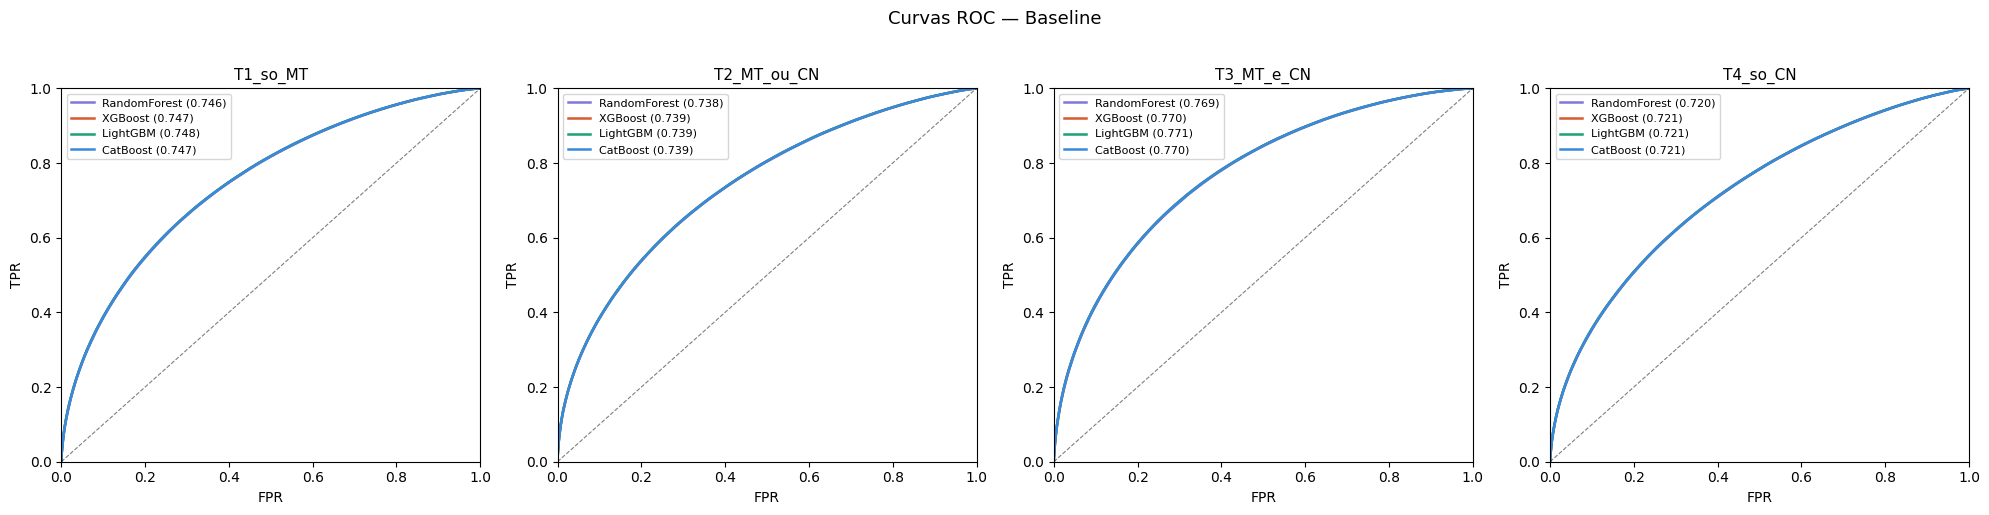

In [ ]:
# ── 7c. Curvas ROC — uma figura por target, todos os modelos sobrepostos ────
CORES = {"RandomForest": "#7F77DD", "XGBoost": "#D85A30", "LightGBM": "#1D9E75", "CatBoost": "#378ADD"}

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, nome_t in zip(axes, NOMES_TARGETS):
    for nome_m in NOMES_MODELOS:
        m = resultados_baseline[(nome_t, nome_m)]
        fpr, tpr, _ = roc_curve(m["y_test"], m["y_proba"])
        ax.plot(fpr, tpr, label=f"{nome_m} ({m['roc_auc']:.3f})", color=CORES[nome_m], lw=1.8)
    ax.plot([0,1],[0,1], "k--", lw=0.8, alpha=0.5)
    ax.set_title(nome_t, fontsize=11)
    ax.set_xlabel("FPR"); ax.set_ylabel("TPR")
    ax.legend(fontsize=8); ax.set_xlim(0,1); ax.set_ylim(0,1)
plt.suptitle("Curvas ROC — Baseline", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("resultados/02_roc_baseline.png", dpi=150, bbox_inches="tight")
plt.show()


## 8. Tuning de hiperparâmetros com Optuna

In [ ]:
# ── 8. Funções de tuning por modelo com Optuna ─────────────────────────────────────────
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
N_TRIALS = 40   # aumente para maior qualidade (ex: 50-100)

def tune_rf(trial, X_tr, y_tr):
    params = dict(
        n_estimators     = trial.suggest_int("n_estimators", 50, 400),
        max_depth        = trial.suggest_int("max_depth", 5, 25),
        min_samples_split= trial.suggest_int("min_samples_split", 10, 100),
        max_features     = trial.suggest_float("max_features", 0.3, 1.0),
        class_weight     = "balanced", n_jobs=-1, random_state=42,
    )
    modelo = RandomForestClassifier(**params)
    return np.mean(cross_val_score_auc(modelo, X_tr, y_tr))

def tune_xgb(trial, X_tr, y_tr):
    params = dict(
        n_estimators = trial.suggest_int("n_estimators", 100, 600),
        max_depth    = trial.suggest_int("max_depth", 3, 10),
        learning_rate= trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        reg_alpha    = trial.suggest_float("reg_alpha", 1e-3, 10, log=True),
        reg_lambda   = trial.suggest_float("reg_lambda", 1e-3, 10, log=True),
        subsample    = trial.suggest_float("subsample", 0.6, 1.0),
        eval_metric="logloss", n_jobs=-1, random_state=42, verbosity=0,
    )
    return np.mean(cross_val_score_auc(XGBClassifier(**params), X_tr, y_tr))

def tune_lgbm(trial, X_tr, y_tr):
    params = dict(
        n_estimators     = trial.suggest_int("n_estimators", 100, 600),
        num_leaves       = trial.suggest_int("num_leaves", 20, 200),
        learning_rate    = trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        min_child_samples= trial.suggest_int("min_child_samples", 10, 100),
        feature_fraction = trial.suggest_float("feature_fraction", 0.5, 1.0),
        class_weight="balanced", n_jobs=-1, random_state=42, verbose=-1,
    )
    return np.mean(cross_val_score_auc(LGBMClassifier(**params), X_tr, y_tr))

def tune_cat(trial, X_tr, y_tr):
    params = dict(
        iterations   = trial.suggest_int("iterations", 100, 600),
        depth        = trial.suggest_int("depth", 4, 10),
        learning_rate= trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        l2_leaf_reg  = trial.suggest_float("l2_leaf_reg", 1, 10),
        auto_class_weights="Balanced",
        cat_features = CAT_IDX if CAT_IDX else None,
        random_seed=42, verbose=0,
    )
    return np.mean(cross_val_score_auc(CatBoostClassifier(**params), X_tr, y_tr))

TUNE_FNS = {
    "RandomForest": tune_rf,
    "XGBoost":      tune_xgb,
    "LightGBM":     tune_lgbm,
    "CatBoost":     tune_cat,
}

def cross_val_score_auc(modelo, X_tr, y_tr):
    scores = []
    for tr_idx, val_idx in CV.split(X_tr, y_tr):
        modelo.fit(X_tr.iloc[tr_idx], y_tr.iloc[tr_idx])
        proba = modelo.predict_proba(X_tr.iloc[val_idx])[:, 1]
        scores.append(roc_auc_score(y_tr.iloc[val_idx], proba))
    return scores

print("Funções de tuning definidas.")


Funções de tuning definidas.


In [ ]:
# ── 8. Tuning otimizado para memória + Progresso) ─────
"""
Este módulo executa a otimização de hiperparâmetros (Tuning) usando o Optuna.
Focado em ambientes com restrição de memória (RAM), ele aplica técnicas como:
1. Downcasting de tipos numéricos (float64 -> float32).
2. Subamostragem (usando apenas 10% dos dados para encontrar os parâmetros).
3. Coleta de lixo (Garbage Collection) a cada ciclo.
4. Uso do método 'hist' no XGBoost para otimização de CPU/RAM.
"""

# --- CONFIGURAÇÕES DO TUNING (Controle de Custo Computacional) ---
N_TRIALS      = 15      # Número de iterações por modelo (aumente para 50+ se tiver tempo/recursos)
FRAC_OPTUNA   = 0.10    # Fração dos dados de treino usada pelo Optuna (salva muita RAM e tempo)
N_JOBS_OPTUNA = 1       # Optuna sequencial: previne falhas de alocação de memória (bad allocation)
N_JOBS_MODEL  = 2       # Limita a CPU a 2 threads por modelo para evitar travamentos do sistema

# --- Dicionários para armazenar os artefatos finais ---
melhores_params  = {}
resultados_tuned = {}
modelos_tuned    = {}


# ── 1. Função de Downcast de Memória ────────────────────────────────────────
def reduzir_memoria(df):
    """
    Reduz o consumo de RAM do DataFrame cortando a precisão dos dados pela metade.
    Converte variáveis float64/int64 (8 bytes) para float32/int32 (4 bytes).
    """
    for col in df.columns:
        if df[col].dtype == 'float64':
            df[col] = df[col].astype('float32')
        elif df[col].dtype == 'int64':
            df[col] = df[col].astype('int32')
    return df


# ── 2. Amostragem Única para o Optuna ───────────────────────────────────────
def preparar_dados_optuna(X_tr, y_tr, frac=FRAC_OPTUNA):
    """
    Cria uma versão reduzida e estratificada dos dados de treino especificamente 
    para a etapa de busca de hiperparâmetros, evitando sobrecarga de memória.

    Args:
        X_tr, y_tr: Conjuntos completos de treino.
        frac (float): Fração dos dados a ser mantida (ex: 0.10 = 10%).

    Returns:
        Tupla com (X_treino_opt, X_val_opt, y_treino_opt, y_val_opt).
    """
    # 1. Pega apenas a fração desejada mantendo a proporção das classes (Stratified)
    sss = StratifiedShuffleSplit(n_splits=1, train_size=frac, random_state=42)
    idx_optuna, _ = next(sss.split(X_tr, y_tr))
    X_opt = X_tr.iloc[idx_optuna].copy()
    y_opt = y_tr.iloc[idx_optuna].copy()
    
    # 2. Divide esse mini-dataset em Treino/Validação (80/20) para o Optuna avaliar
    X_t_tr, X_t_val, y_t_tr, y_t_val = train_test_split(
        X_opt, y_opt, test_size=0.2, stratify=y_opt, random_state=42
    )
    
    # Limpa as variáveis intermediárias da memória
    del X_opt, y_opt
    gc.collect()
    
    return X_t_tr, X_t_val, y_t_tr, y_t_val


# ── 3. Funções Objetivo do Optuna (Tuning por Modelo) ───────────────────────
# As funções abaixo definem os espaços de busca (search spaces) para cada algoritmo.

def tune_lgbm(trial, X_tr, y_tr, X_val, y_val):
    modelo = LGBMClassifier(
        n_estimators      = trial.suggest_int("n_estimators", 100, 300),
        num_leaves        = trial.suggest_int("num_leaves", 20, 80),
        learning_rate     = trial.suggest_float("learning_rate", 0.02, 0.3, log=True),
        min_child_samples = trial.suggest_int("min_child_samples", 20, 150),
        feature_fraction  = trial.suggest_float("feature_fraction", 0.5, 1.0),
        class_weight      = "balanced",
        n_jobs            = N_JOBS_MODEL,
        random_state      = 42,
        verbose           = -1,
    )
    modelo.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        callbacks=[
            __import__("lightgbm").early_stopping(20, verbose=False),
            __import__("lightgbm").log_evaluation(-1),
        ],
    )
    proba = modelo.predict_proba(X_val)[:, 1]
    return float(roc_auc_score(y_val, proba))

def tune_xgb(trial, X_tr, y_tr, X_val, y_val):
    modelo = XGBClassifier(
        n_estimators  = trial.suggest_int("n_estimators", 100, 300),
        max_depth     = trial.suggest_int("max_depth", 3, 7),
        learning_rate = trial.suggest_float("learning_rate", 0.02, 0.3, log=True),
        reg_alpha     = trial.suggest_float("reg_alpha", 1e-3, 5.0, log=True),
        reg_lambda    = trial.suggest_float("reg_lambda", 1e-3, 5.0, log=True),
        subsample     = trial.suggest_float("subsample", 0.6, 1.0),
        tree_method   = "hist", # CRÍTICO: Usa histogramas, economizando muita memória/tempo
        eval_metric   = "logloss",
        early_stopping_rounds = 20,
        n_jobs        = N_JOBS_MODEL,
        random_state  = 42,
        verbosity     = 0,
    )
    modelo.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
    proba = modelo.predict_proba(X_val)[:, 1]
    return float(roc_auc_score(y_val, proba))

def tune_cat(trial, X_tr, y_tr, X_val, y_val):
    modelo = CatBoostClassifier(
        iterations        = trial.suggest_int("iterations", 100, 300),
        depth             = trial.suggest_int("depth", 4, 7),
        learning_rate     = trial.suggest_float("learning_rate", 0.02, 0.3, log=True),
        l2_leaf_reg       = trial.suggest_float("l2_leaf_reg", 1.0, 10.0),
        auto_class_weights= "Balanced",
        cat_features      = CAT_IDX if 'CAT_IDX' in globals() and CAT_IDX else None,
        early_stopping_rounds = 20,
        thread_count      = N_JOBS_MODEL, 
        random_seed       = 42,
        verbose           = 0,
    )
    modelo.fit(X_tr, y_tr, eval_set=(X_val, y_val), verbose=False)
    proba = modelo.predict_proba(X_val)[:, 1]
    return float(roc_auc_score(y_val, proba))

def tune_rf(trial, X_tr, y_tr, X_val, y_val):
    modelo = RandomForestClassifier(
        n_estimators      = trial.suggest_int("n_estimators", 50, 120),
        max_depth         = trial.suggest_int("max_depth", 5, 12),
        min_samples_split = trial.suggest_int("min_samples_split", 20, 150),
        max_features      = trial.suggest_float("max_features", 0.3, 0.8),
        class_weight      = "balanced",
        n_jobs            = N_JOBS_MODEL,
        random_state      = 42,
    )
    modelo.fit(X_tr, y_tr) # RF não suporta early stopping nativamente da mesma forma
    proba = modelo.predict_proba(X_val)[:, 1]
    return float(roc_auc_score(y_val, proba))

# Mapeamento dinâmico: Prioriza os modelos nativamente mais rápidos primeiro
TUNE_FNS_OPT = {
    "LightGBM":     tune_lgbm,
    "XGBoost":      tune_xgb,
    "CatBoost":     tune_cat,
    "RandomForest": tune_rf, 
}


# ── 4. Função Orquestradora de Tuning (1 Target + 1 Modelo) ─────────────────
def rodar_tuning(nome_t, nome_m, X_train, y_train, X_test, y_test):
    """
    Gerencia o ciclo de vida completo do tuning para uma combinação específica 
    de modelo e target: redução de memória -> Optuna Study -> Treinamento Final.
    """
    tune_fn = TUNE_FNS_OPT[nome_m]

    # 1. Otimização de Memória nos dados de entrada
    X_train = reduzir_memoria(X_train)
    X_test  = reduzir_memoria(X_test)

    # 2. Criação da Sub-amostra para o Optuna
    X_t_tr, X_t_val, y_t_tr, y_t_val = preparar_dados_optuna(X_train, y_train)

    # 3. Configuração do Estudo Optuna (TPESampler com MedianPruner para cortar trials ruins)
    study = optuna.create_study(
        direction = "maximize", # Queremos maximizar o ROC-AUC
        sampler   = optuna.samplers.TPESampler(seed=42, multivariate=True),
        pruner    = MedianPruner(n_startup_trials=5, n_warmup_steps=3),
    )
    
    # 4. Execução da Otimização
    study.optimize(
        lambda trial: tune_fn(trial, X_t_tr, y_t_tr, X_t_val, y_t_val),
        n_trials          = N_TRIALS,
        n_jobs            = N_JOBS_OPTUNA, 
        show_progress_bar = True,  # Exibe progresso visual no console
    )

    best_p = study.best_params

    # 5. Limpeza Agressiva de RAM (Esvazia as variáveis temporárias do Optuna)
    del X_t_tr, X_t_val, y_t_tr, y_t_val
    gc.collect()

    print(f"\n    > Treinando {nome_m} final com 100% do dataset de treino...")

    # 6. Re-instanciação do modelo com os MELHORES parâmetros encontrados
    if nome_m == "LightGBM":
        modelo_final = LGBMClassifier(**best_p, class_weight="balanced", n_jobs=N_JOBS_MODEL, random_state=42, verbose=-1)
    elif nome_m == "XGBoost":
        modelo_final = XGBClassifier(**best_p, tree_method="hist", eval_metric="logloss", n_jobs=N_JOBS_MODEL, random_state=42, verbosity=0)
    elif nome_m == "CatBoost":
        modelo_final = CatBoostClassifier(**best_p, auto_class_weights="Balanced", cat_features=CAT_IDX if 'CAT_IDX' in globals() and CAT_IDX else None, thread_count=N_JOBS_MODEL, random_seed=42, verbose=0)
    else:
        # Garante um mínimo de árvores para o Random Forest final
        best_p_final = {**best_p, "n_estimators": max(best_p["n_estimators"], 120)}
        modelo_final = RandomForestClassifier(**best_p_final, class_weight="balanced", n_jobs=N_JOBS_MODEL, random_state=42)

    # 7. Treinamento Definitivo e Inferência
    modelo_final.fit(X_train, y_train)
    y_pred  = modelo_final.predict(X_test)
    y_proba = modelo_final.predict_proba(X_test)[:, 1]

    # 8. Cálculo de Métricas Finais
    metricas = dict(
        roc_auc   = roc_auc_score(y_test, y_proba),
        f1        = f1_score(y_test, y_pred, zero_division=0),
        precision = precision_score(y_test, y_pred, zero_division=0),
        recall    = recall_score(y_test, y_pred, zero_division=0),
        y_test    = y_test,
        y_pred    = y_pred,
        y_proba   = y_proba,
    )
    
    return nome_t, nome_m, best_p, metricas, modelo_final


# ── 5. Execução Principal (Main Loop) ───────────────────────────────────────
t0 = time.time()

# Prepara a fila de tarefas copiando os splits originais
tarefas = [
    (nome_t, nome_m,
     splits_por_target[nome_t][0].copy(),   # X_train
     splits_por_target[nome_t][2].copy(),   # y_train
     splits_por_target[nome_t][1].copy(),   # X_test
     splits_por_target[nome_t][3].copy())   # y_test
    for nome_t in TARGETS
    for nome_m in TUNE_FNS_OPT
]

print(f"Iniciando tuning otimizado ({N_TRIALS} trials | Single Val | Barra Ligada)...\n")

for nome_t, nome_m, X_tr, y_tr, X_te, y_te in tarefas:
    print("=" * 60)
    print(f"🚀 INICIANDO: Alvo = {nome_t} | Modelo = {nome_m}")
    print("=" * 60)
    
    # Roda a pipeline de tuning para esta iteração
    nome_t, nome_m, best_p, metricas, modelo = rodar_tuning(nome_t, nome_m, X_tr, y_tr, X_te, y_te)
    
    # Salva os resultados nos dicionários globais
    melhores_params[(nome_t, nome_m)]  = best_p
    resultados_tuned[(nome_t, nome_m)] = metricas
    modelos_tuned[(nome_t, nome_m)]    = modelo
    
    # Tenta calcular a melhoria (Delta) em relação ao baseline, se ele existir na memória
    try:
        delta = metricas["roc_auc"] - resultados_baseline[(nome_t, nome_m)]["roc_auc"]
        print(f"    > ✅ Concluído: AUC = {metricas['roc_auc']:.4f}  | Δ = {delta:+.4f} (vs Baseline)\n")
    except (KeyError, NameError):
        # Fallback caso a variável 'resultados_baseline' não tenha sido definida
        print(f"    > ✅ Concluído: AUC = {metricas['roc_auc']:.4f}\n")
    
    # 9. Limpeza final pós-modelo 
    del X_tr, y_tr, X_te, y_te
    gc.collect()

print(f"\n🎉 Tuning total concluído com sucesso em {(time.time() - t0) / 60:.1f} min!")

Iniciando tuning ultraleve (15 trials | Single Val | Barra Ligada)...

🚀 INICIANDO: Alvo = T1_so_MT | Modelo = LightGBM


Best trial: 13. Best value: 0.746096: 100%|██████████| 15/15 [02:44<00:00, 10.96s/it]



    > Treinando LightGBM final com todo o dataset...
  > ✅ Concluído: AUC=0.7475  Δ=+0.0000

🚀 INICIANDO: Alvo = T1_so_MT | Modelo = XGBoost


Best trial: 11. Best value: 0.745855: 100%|██████████| 15/15 [04:44<00:00, 18.93s/it]



    > Treinando XGBoost final com todo o dataset...
  > ✅ Concluído: AUC=0.7474  Δ=-0.0000

🚀 INICIANDO: Alvo = T1_so_MT | Modelo = CatBoost


Best trial: 8. Best value: 0.746073: 100%|██████████| 15/15 [06:54<00:00, 27.66s/it]



    > Treinando CatBoost final com todo o dataset...
  > ✅ Concluído: AUC=0.7476  Δ=+0.0005

🚀 INICIANDO: Alvo = T1_so_MT | Modelo = RandomForest


Best trial: 14. Best value: 0.742968: 100%|██████████| 15/15 [25:04<00:00, 100.27s/it]



    > Treinando RandomForest final com todo o dataset...
  > ✅ Concluído: AUC=0.7443  Δ=-0.0017

🚀 INICIANDO: Alvo = T2_MT_ou_CN | Modelo = LightGBM


Best trial: 14. Best value: 0.739456: 100%|██████████| 15/15 [02:58<00:00, 11.89s/it]



    > Treinando LightGBM final com todo o dataset...
  > ✅ Concluído: AUC=0.7392  Δ=-0.0002

🚀 INICIANDO: Alvo = T2_MT_ou_CN | Modelo = XGBoost


Best trial: 11. Best value: 0.739419: 100%|██████████| 15/15 [04:21<00:00, 17.42s/it]



    > Treinando XGBoost final com todo o dataset...
  > ✅ Concluído: AUC=0.7394  Δ=-0.0000

🚀 INICIANDO: Alvo = T2_MT_ou_CN | Modelo = CatBoost


Best trial: 14. Best value: 0.739573: 100%|██████████| 15/15 [06:49<00:00, 27.27s/it]



    > Treinando CatBoost final com todo o dataset...
  > ✅ Concluído: AUC=0.7394  Δ=+0.0004

🚀 INICIANDO: Alvo = T2_MT_ou_CN | Modelo = RandomForest


Best trial: 13. Best value: 0.736909: 100%|██████████| 15/15 [21:26<00:00, 85.80s/it]



    > Treinando RandomForest final com todo o dataset...
  > ✅ Concluído: AUC=0.7368  Δ=-0.0013

🚀 INICIANDO: Alvo = T3_MT_e_CN | Modelo = LightGBM


Best trial: 11. Best value: 0.768505: 100%|██████████| 15/15 [02:31<00:00, 10.11s/it]



    > Treinando LightGBM final com todo o dataset...
  > ✅ Concluído: AUC=0.7707  Δ=+0.0002

🚀 INICIANDO: Alvo = T3_MT_e_CN | Modelo = XGBoost


Best trial: 8. Best value: 0.768141: 100%|██████████| 15/15 [03:51<00:00, 15.42s/it]



    > Treinando XGBoost final com todo o dataset...
  > ✅ Concluído: AUC=0.7698  Δ=-0.0006

🚀 INICIANDO: Alvo = T3_MT_e_CN | Modelo = CatBoost


Best trial: 11. Best value: 0.768701: 100%|██████████| 15/15 [07:00<00:00, 28.06s/it]



    > Treinando CatBoost final com todo o dataset...
  > ✅ Concluído: AUC=0.7707  Δ=+0.0005

🚀 INICIANDO: Alvo = T3_MT_e_CN | Modelo = RandomForest


Best trial: 14. Best value: 0.765187: 100%|██████████| 15/15 [22:01<00:00, 88.12s/it] 



    > Treinando RandomForest final com todo o dataset...
  > ✅ Concluído: AUC=0.7672  Δ=-0.0017

🚀 INICIANDO: Alvo = T4_so_CN | Modelo = LightGBM


Best trial: 13. Best value: 0.720402: 100%|██████████| 15/15 [02:42<00:00, 10.84s/it]



    > Treinando LightGBM final com todo o dataset...
  > ✅ Concluído: AUC=0.7211  Δ=+0.0001

🚀 INICIANDO: Alvo = T4_so_CN | Modelo = XGBoost


Best trial: 12. Best value: 0.720184: 100%|██████████| 15/15 [04:10<00:00, 16.72s/it]



    > Treinando XGBoost final com todo o dataset...
  > ✅ Concluído: AUC=0.7209  Δ=-0.0001

🚀 INICIANDO: Alvo = T4_so_CN | Modelo = CatBoost


Best trial: 0. Best value: 0.720356: 100%|██████████| 15/15 [06:44<00:00, 26.96s/it]



    > Treinando CatBoost final com todo o dataset...
  > ✅ Concluído: AUC=0.7211  Δ=+0.0004

🚀 INICIANDO: Alvo = T4_so_CN | Modelo = RandomForest


Best trial: 14. Best value: 0.718112: 100%|██████████| 15/15 [24:59<00:00, 99.95s/it] 



    > Treinando RandomForest final com todo o dataset...
  > ✅ Concluído: AUC=0.7184  Δ=-0.0013


🎉 Tuning total concluído com sucesso em 377.2 min


## 9. Comparação final — baseline vs tuned

In [ ]:
# ── 9a. Relatório: Tabela Comparativa (Baseline vs Tuned) ───────────────────

def gerar_tabela_comparativa():
    """
    Constrói, exibe e salva um relatório consolidado comparando a performance 
    dos modelos antes (Baseline) e depois da otimização de hiperparâmetros (Tuned).

    A função calcula o ganho de performance (Δ_AUC) para evidenciar se o tempo 
    gasto no tuning pelo Optuna se traduziu em melhorias reais. Caso algum modelo 
    não tenha passado pelo tuning, a função faz um "fallback" seguro, repetindo 
    os resultados do baseline para evitar quebra no código.

    Returns:
        pd.DataFrame: Tabela comparativa ordenada pelos melhores resultados de 
            ROC-AUC otimizados. Adicionalmente, salva um arquivo CSV em disco.
    """
    linhas_tabela = []

    # 1. Agregação dos Dados
    # Itera sobre todos os targets (variáveis resposta) e modelos disponíveis
    for nome_t in TARGETS:
        for nome_m in TUNE_FNS_OPT:
            
            # Recupera as métricas do modelo com hiperparâmetros padrão (Baseline)
            b = resultados_baseline[(nome_t, nome_m)]
            
            # Recupera as métricas do modelo otimizado (Tuned).
            # O .get() funciona como um sistema de segurança (fallback): se por algum 
            # motivo a iteração do Optuna falhou e não salvou no dicionário, 
            # ele retorna as métricas do baseline 'b' no lugar.
            t = resultados_tuned.get((nome_t, nome_m), b)
            
            # Monta a linha do relatório
            linhas_tabela.append({
                "Target": nome_t, 
                "Modelo": nome_m,
                "AUC_baseline": b["roc_auc"], 
                "AUC_tuned": t["roc_auc"],
                "F1_baseline": b["f1"],      
                "F1_tuned": t["f1"],
                # Calcula o "Delta": o quanto o modelo melhorou (ou piorou) após o tuning
                "Δ_AUC": t["roc_auc"] - b["roc_auc"],
            })

    # 2. Criação e Formatação do DataFrame
    df_comp = pd.DataFrame(linhas_tabela)
    
    # Ordena a tabela do melhor para o pior modelo com base no AUC Otimizado
    df_comp = df_comp.sort_values(by="AUC_tuned", ascending=False)
    
    # 3. Exibição no Console
    print("🏆 Relatório Comparativo Final (Baseline vs Tuned):")
    print("-" * 75)
    # Exibe a tabela arredondando para 4 casas decimais e ocultando o índice numérico
    print(df_comp.round(4).to_string(index=False))
    print("-" * 75)

    # 4. Exportação dos Dados
    caminho_salvamento = "resultados/comparativo_final.csv"
    df_comp.to_csv(caminho_salvamento, index=False)
    print(f"💾 Tabela salva com sucesso em: {caminho_salvamento}")
    
    return df_comp

# --- Execução da Função ---
# Armazena o DataFrame resultante caso você queira usá-lo em outros blocos
df_comparativo = gerar_tabela_comparativa()

     Target       Modelo  AUC_baseline  AUC_tuned  F1_baseline  F1_tuned   Δ_AUC
 T3_MT_e_CN     CatBoost        0.7702     0.7707       0.6192    0.6197  0.0005
 T3_MT_e_CN     LightGBM        0.7705     0.7707       0.6193    0.6195  0.0002
 T3_MT_e_CN      XGBoost        0.7704     0.7698       0.5506    0.5498 -0.0006
 T3_MT_e_CN RandomForest        0.7689     0.7672       0.6176    0.6164 -0.0017
   T1_so_MT     CatBoost        0.7471     0.7476       0.6724    0.6726  0.0005
   T1_so_MT     LightGBM        0.7475     0.7475       0.6726    0.6724  0.0000
   T1_so_MT      XGBoost        0.7474     0.7474       0.6726    0.6725 -0.0000
   T1_so_MT RandomForest        0.7460     0.7443       0.6702    0.6695 -0.0017
T2_MT_ou_CN     CatBoost        0.7390     0.7394       0.7091    0.7094  0.0004
T2_MT_ou_CN      XGBoost        0.7394     0.7394       0.7864    0.7865 -0.0000
T2_MT_ou_CN     LightGBM        0.7394     0.7392       0.7086    0.7090 -0.0002
T2_MT_ou_CN RandomForest    

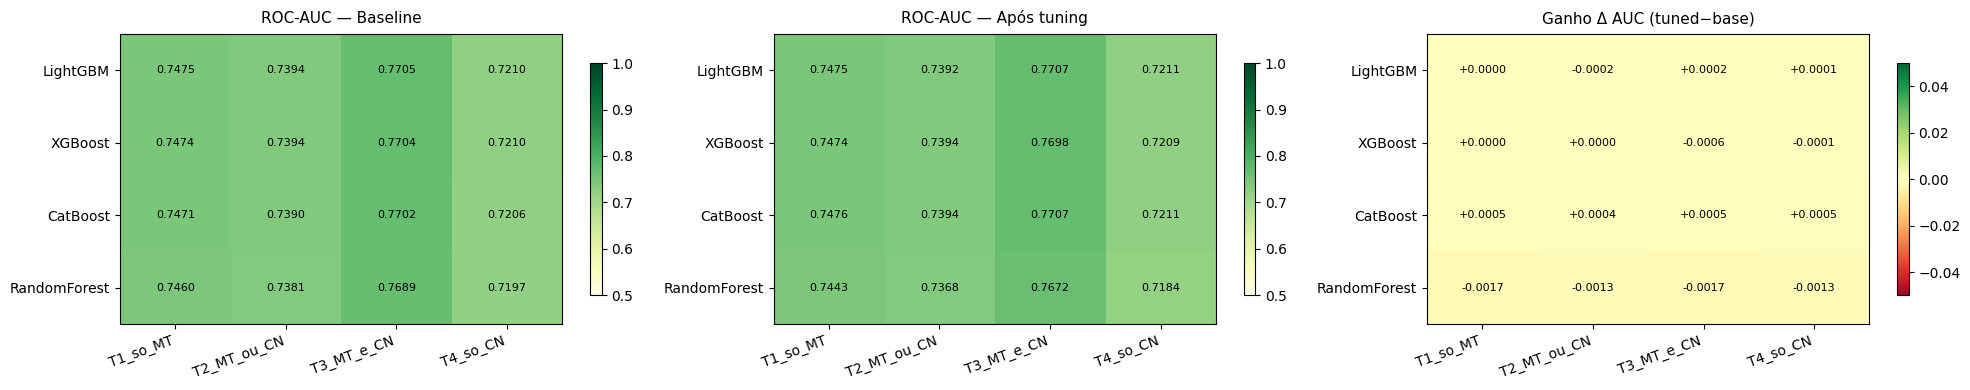

In [ ]:
# ── 9b. Heatmap baseline vs tuned ───────────────────────────────────────────
def make_tab(fonte):
    # Pega os nomes dos modelos diretamente das chaves do dicionário de tuning atual
    modelos = list(TUNE_FNS_OPT.keys())
    return pd.DataFrame(
        [[fonte[(t, m)]["roc_auc"] for t in TARGETS] for m in modelos],
        index=modelos, columns=TARGETS,
    ).round(4)

# Cria as tabelas
tab_base  = make_tab(resultados_baseline)
tab_tuned = make_tab(resultados_tuned)
tab_delta = tab_tuned - tab_base

# Prepara a figura com 3 subplots lado a lado
fig, axes = plt.subplots(1, 3, figsize=(20, 4))

configs = [
    (tab_base,  "ROC-AUC — Baseline",      "YlGn",   0.5, 1.0),
    (tab_tuned, "ROC-AUC — Após tuning",   "YlGn",   0.5, 1.0),
    (tab_delta, "Ganho Δ AUC (tuned−base)","RdYlGn", -0.05, 0.05),
]

# Correção: O 'zip' une os 3 axes com as 3 configurações do 'configs'
for ax, (tab, titulo, cmap, vmin, vmax) in zip(axes, configs):
    im = ax.imshow(tab.values, cmap=cmap, vmin=vmin, vmax=vmax, aspect="auto")
    
    # Configura eixos X
    ax.set_xticks(range(len(TARGETS)))
    ax.set_xticklabels(TARGETS, rotation=20, ha="right")
    
    # Configura eixos Y
    ax.set_yticks(range(len(tab.index)))
    ax.set_yticklabels(tab.index)
    
    ax.set_title(titulo, fontsize=11, pad=8)
    
    # Preenche os valores numéricos nos quadradinhos
    for i in range(len(tab.index)):
        for j in range(len(TARGETS)):
            v = tab.values[i, j]
            fmt = f"{v:+.4f}" if "Ganho" in titulo else f"{v:.4f}"
            ax.text(j, i, fmt, ha="center", va="center", fontsize=8)
            
    plt.colorbar(im, ax=ax, shrink=0.8)

plt.tight_layout()

# Segurança: Cria a pasta 'resultados' caso ela não exista
os.makedirs("resultados", exist_ok=True)
plt.savefig("resultados/03_heatmap_comparativo.png", dpi=150, bbox_inches="tight")

plt.show()


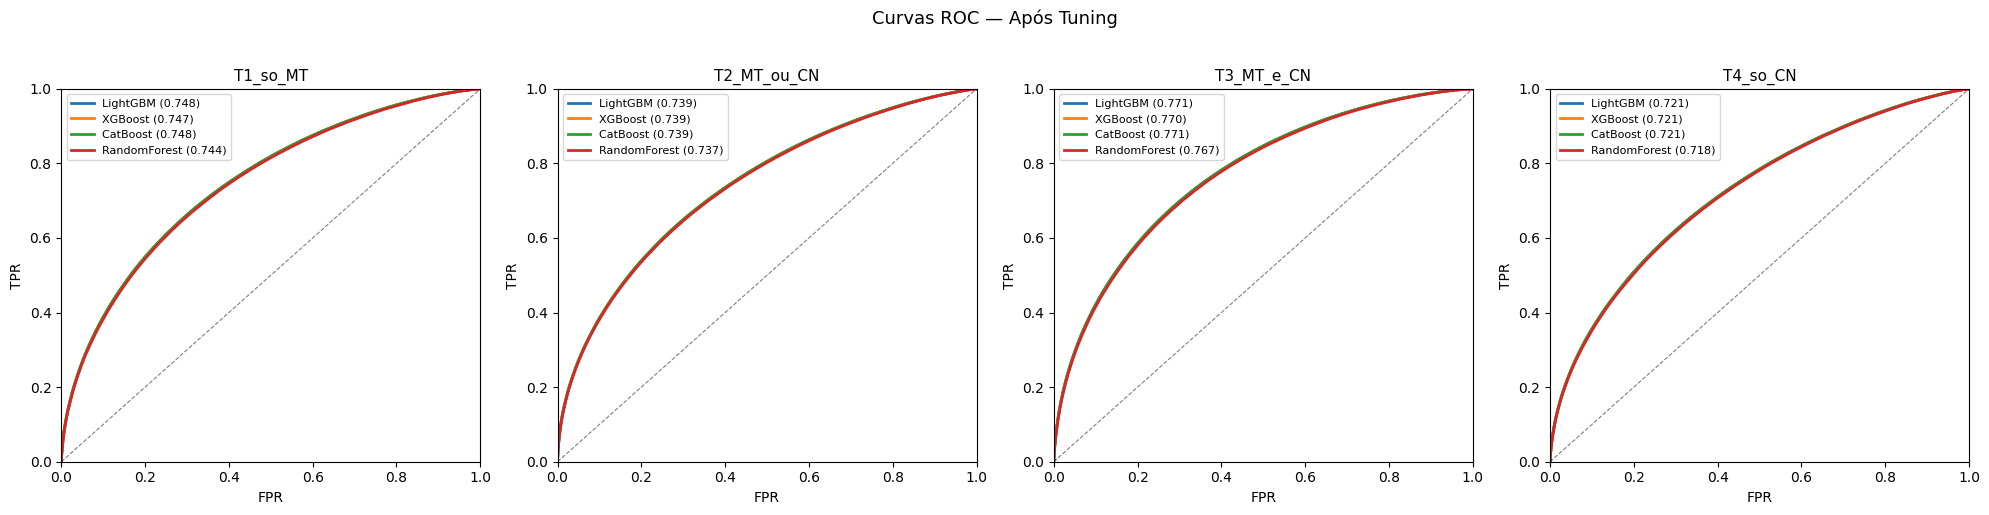

In [ ]:
import os
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

# Paleta de segurança (caso a variável original CORES não esteja mais na RAM)
cores_seguras = {
    "LightGBM": "#1f77b4",    # Azul
    "XGBoost": "#ff7f0e",     # Laranja
    "CatBoost": "#2ca02c",    # Verde
    "RandomForest": "#d62728" # Vermelho
}

# Se a variável CORES existir no seu notebook, ele usa ela. Senão, usa as cores seguras acima.
CORES_ATIVAS = globals().get('CORES', cores_seguras)

# ── 9c. Curvas ROC tuned — todos os modelos por target ──────────────────────

n_targets = len(TARGETS)
# Ajusta o tamanho da figura dinamicamente baseado na quantidade de targets
fig, axes = plt.subplots(1, n_targets, figsize=(5 * n_targets, 5))

# Garante que 'axes' seja sempre uma lista iterável (mesmo se for apenas 1 target)
if n_targets == 1:
    axes = [axes]

for ax, nome_t in zip(axes, TARGETS):
    # Itera sobre a ordem definida lá no dicionário TUNE_FNS_OPT
    for nome_m in TUNE_FNS_OPT:
        
        # Puxa o resultado tuned. Se falhar, tenta o baseline.
        m = resultados_tuned.get((nome_t, nome_m), resultados_baseline.get((nome_t, nome_m)))
        
        # Se por algum motivo o modelo não tiver dados, ele pula a linha e não trava o código
        if m is None:
            continue
            
        fpr, tpr, _ = roc_curve(m["y_test"], m["y_proba"])
        cor = CORES_ATIVAS.get(nome_m, "gray") # Pega a cor correspondente (ou cinza como fallback)
        
        ax.plot(fpr, tpr, label=f"{nome_m} ({m['roc_auc']:.3f})", color=cor, lw=2)
        
    ax.plot([0,1], [0,1], "k--", lw=0.8, alpha=0.5)
    ax.set_title(nome_t, fontsize=11)
    ax.set_xlabel("FPR")
    ax.set_ylabel("TPR")
    ax.legend(fontsize=8)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

plt.suptitle("Curvas ROC — Após Tuning", fontsize=13, y=1.02)
plt.tight_layout()

# Segurança extra para a pasta de salvamento
os.makedirs("resultados", exist_ok=True)
plt.savefig("resultados/04_roc_tuned.png", dpi=150, bbox_inches="tight")

plt.show()

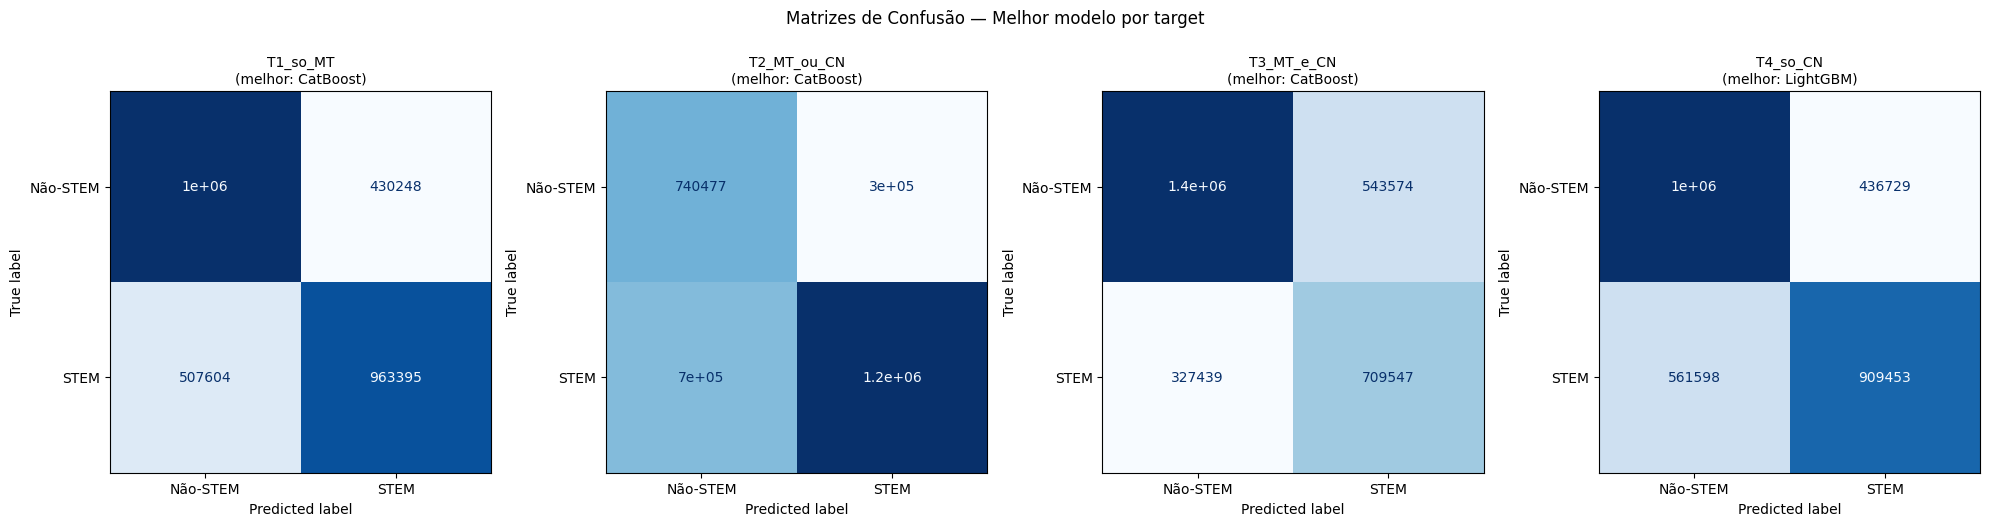

In [ ]:
# ── 9d. Matrizes de confusão — melhor modelo por target ─────────────────────
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, nome_t in zip(axes, TARGETS):
    # Identifica o melhor modelo para esse target
    melhor_m = max(TUNE_FNS_OPT, key=lambda m: resultados_tuned.get(
        (nome_t, m), resultados_baseline[(nome_t, m)])["roc_auc"])
    fonte = resultados_tuned.get((nome_t, melhor_m), resultados_baseline[(nome_t, melhor_m)])
    ConfusionMatrixDisplay.from_predictions(
        fonte["y_test"], fonte["y_pred"],
        display_labels=["Não-STEM", "STEM"],
        cmap="Blues", ax=ax, colorbar=False,
    )
    ax.set_title(f"{nome_t}\n(melhor: {melhor_m})", fontsize=10)
plt.suptitle("Matrizes de Confusão — Melhor modelo por target", y=1.02, fontsize=12)
plt.tight_layout()
plt.savefig("resultados/05_matrizes_confusao.png", dpi=150, bbox_inches="tight")
plt.show()


## 10. Análise SHAP — onde os modelos convergem

In [ ]:
# ── 10a. Configuração SHAP ──────────────────────────────────────────────────
# Usamos uma amostra para o SHAP (cálculo exato é lento em datasets grandes)
N_SHAP = 2000   # aumente se tiver RAM e tempo disponíveis

def get_shap_values(modelo, X_bg, X_explain, nome_m):
    """Retorna shap_values e explainer para qualquer modelo."""
    if nome_m == "RandomForest":
        explainer = shap.TreeExplainer(modelo, data=X_bg, feature_perturbation="interventional")
    elif nome_m in ("XGBoost", "LightGBM", "CatBoost"):
        explainer = shap.TreeExplainer(modelo)
    shap_vals = explainer.shap_values(X_explain)
    # RandomForest retorna lista [classe0, classe1] — pegamos classe 1
    if isinstance(shap_vals, list):
        shap_vals = shap_vals[1]
    return shap_vals, explainer

print("Configuração SHAP OK.")


Configuração SHAP OK.


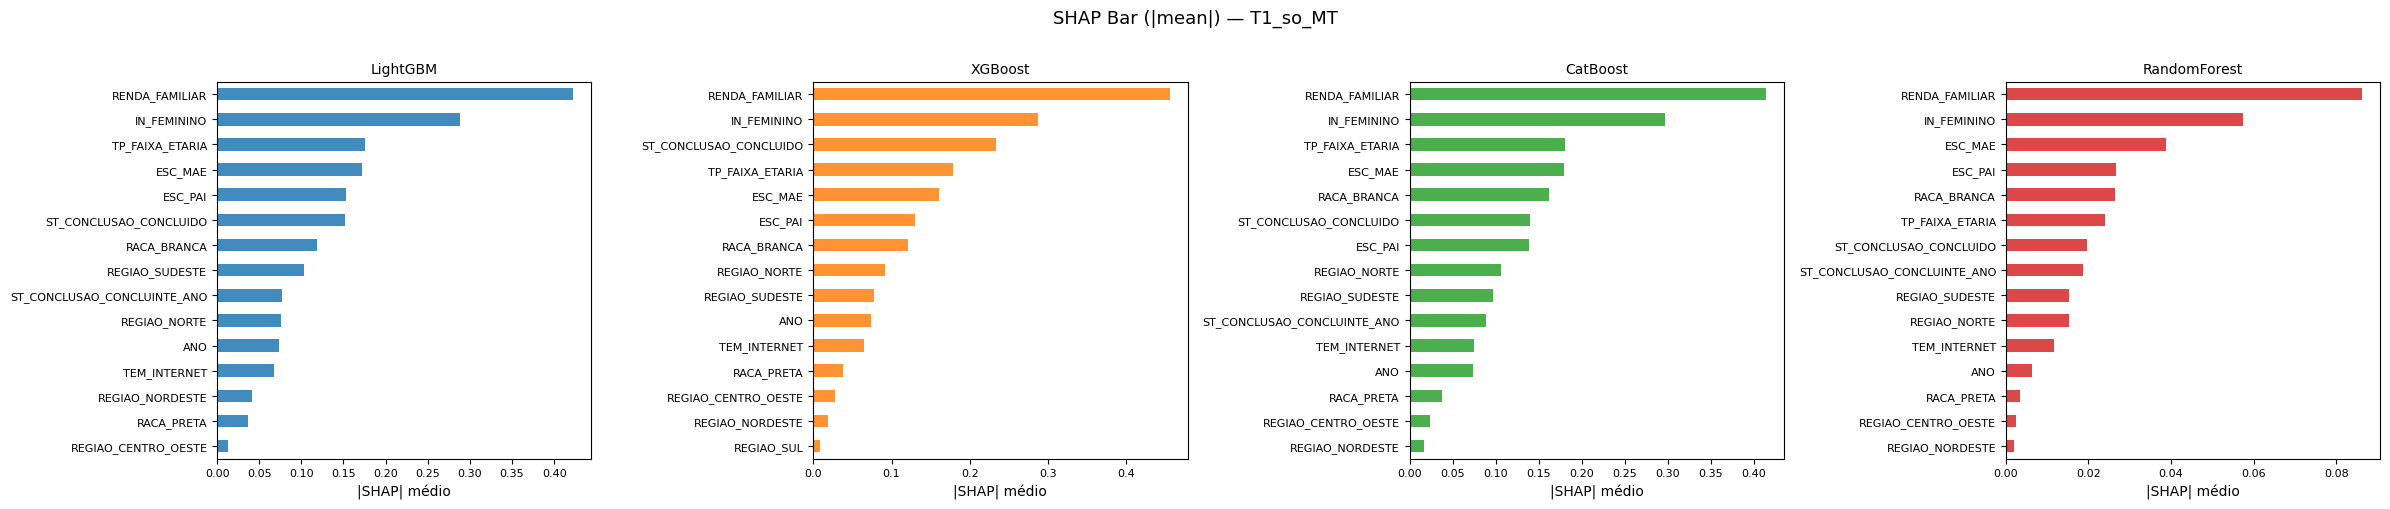

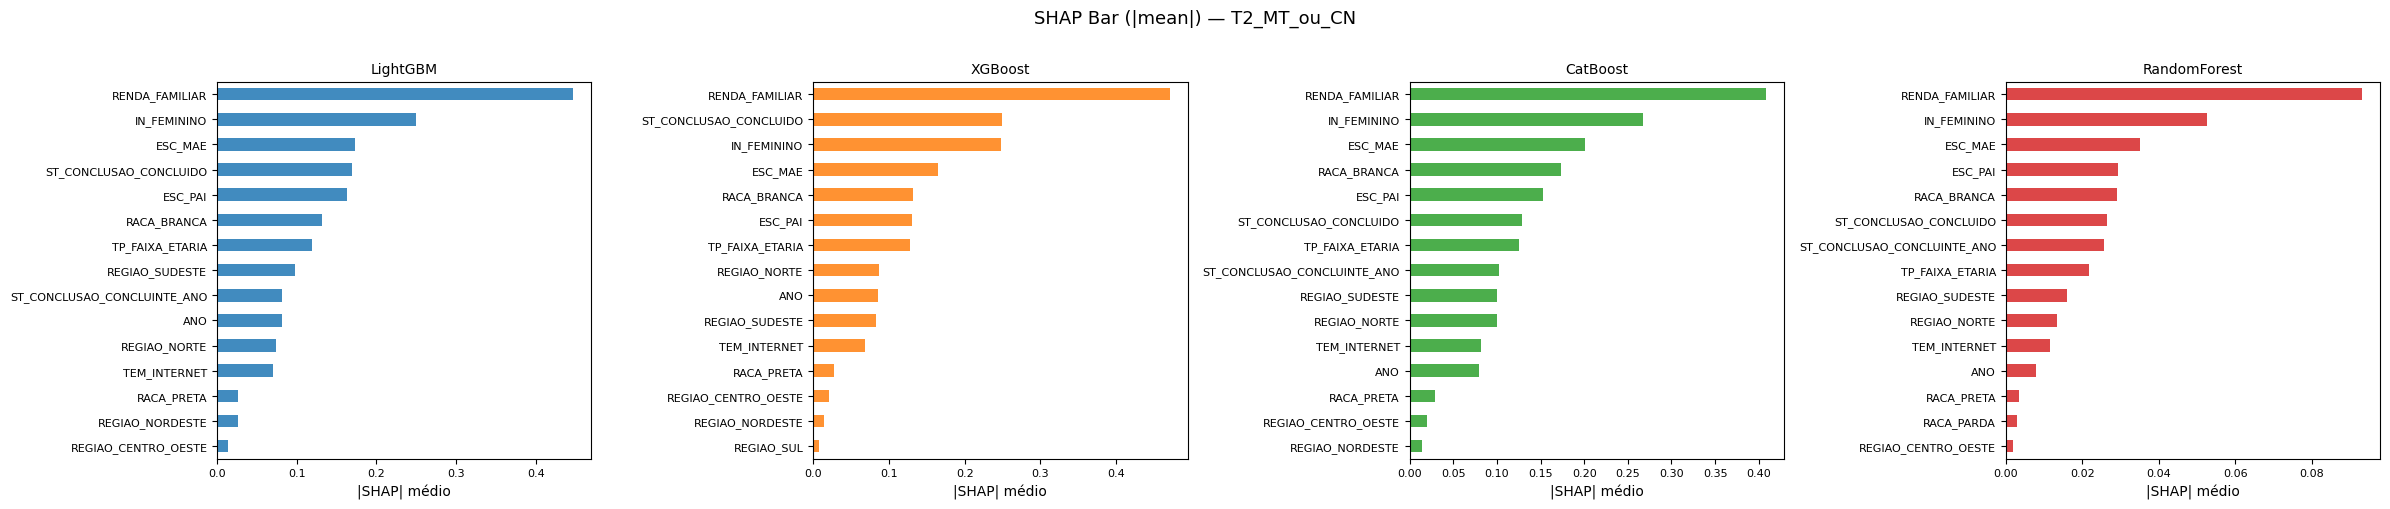

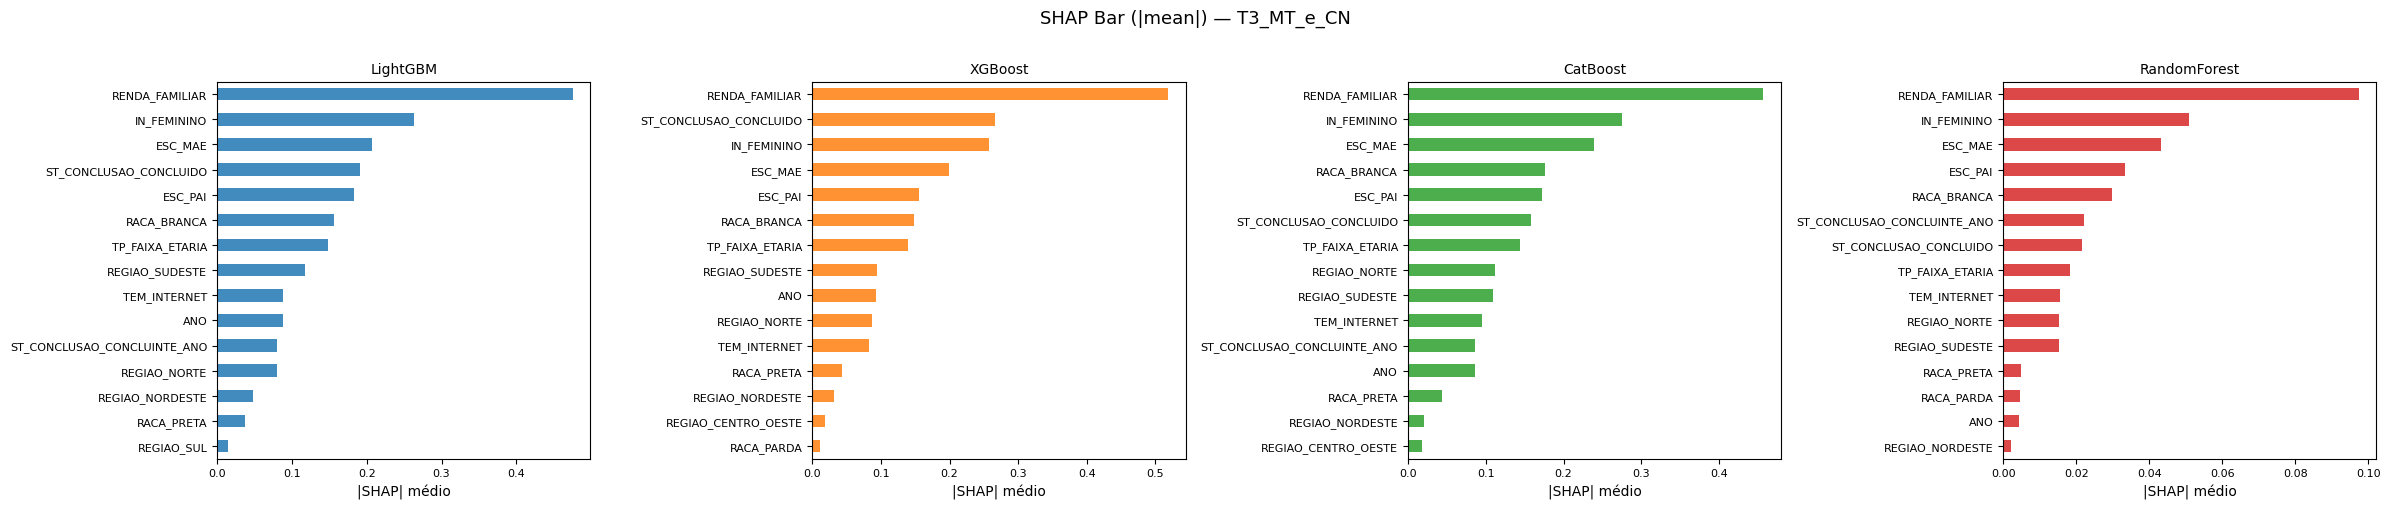

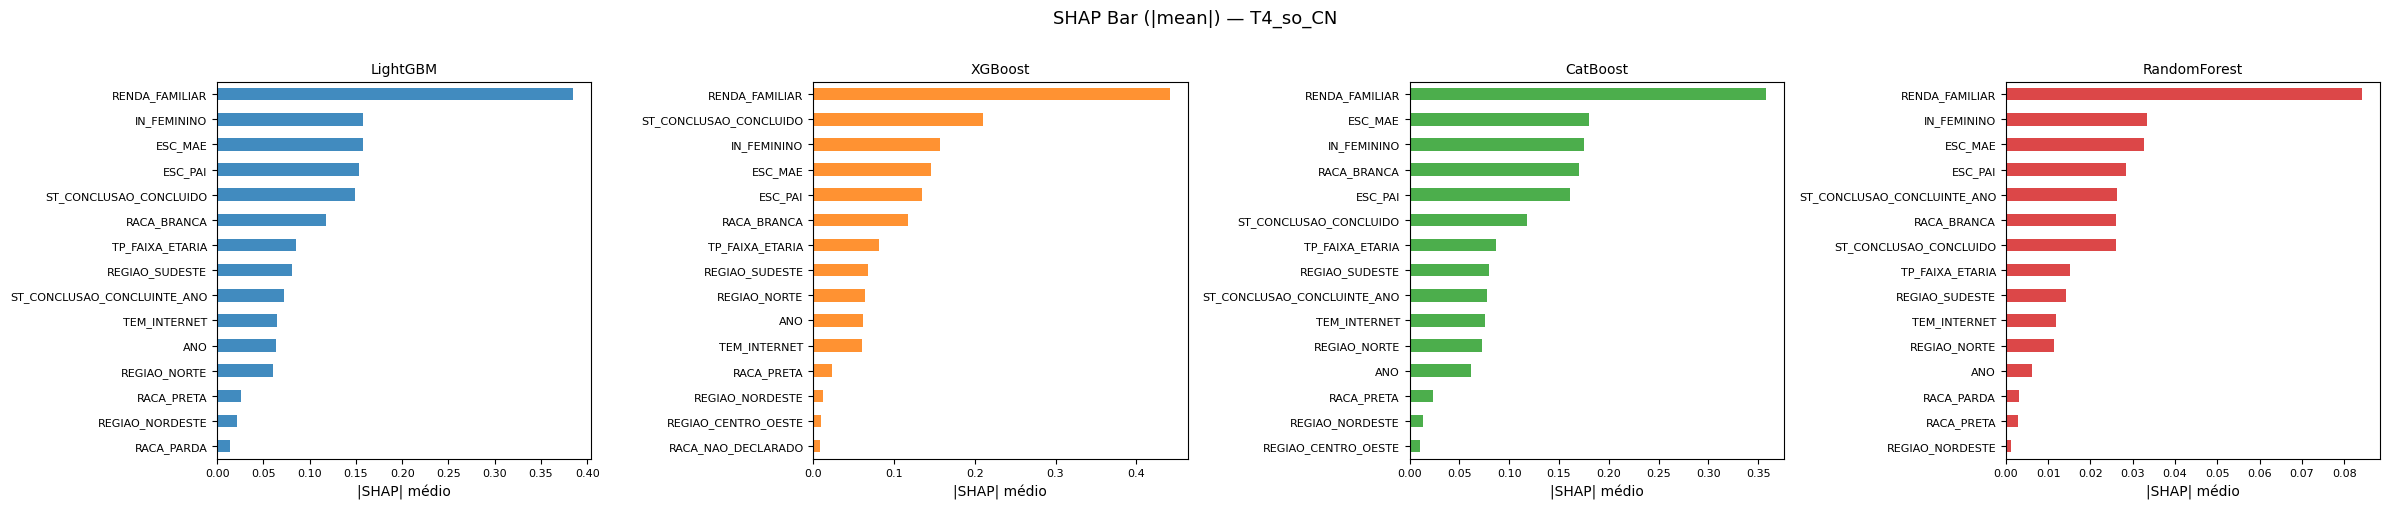

In [ ]:
# Paleta de segurança
cores_seguras = {
    "LightGBM": "#1f77b4",    # Azul
    "XGBoost": "#ff7f0e",     # Laranja
    "CatBoost": "#2ca02c",    # Verde
    "RandomForest": "#d62728" # Vermelho
}

CORES_ATIVAS = globals().get('CORES', cores_seguras)

# ── 10b. Bar plot — importância média |SHAP| por modelo ─────────────────────
# Facilita a leitura da magnitude de impacto de cada feature

for nome_t in TARGETS:
    fig, axes = plt.subplots(1, len(TUNE_FNS_OPT), figsize=(24, 5))
    fig.suptitle(f"SHAP Bar (|mean|) — {nome_t}", fontsize=13, y=1.01)

    if len(TUNE_FNS_OPT) == 1:
        axes = [axes]

    for ax, nome_m in zip(axes, TUNE_FNS_OPT):
        
        if (nome_t, nome_m) not in shap_storage:
            ax.set_title(f"{nome_m} (Sem Dados SHAP)", fontsize=10)
            ax.axis('off')
            continue

        sv = shap_storage[(nome_t, nome_m)]["shap_values"]
        Xe = shap_storage[(nome_t, nome_m)]["X"]

        # ─── CORREÇÃO DE FORMATO SHAP ────────────────────────────────────────
        # Se for uma lista (ex: Random Forest), pega o index [1] (Classe positiva)
        if isinstance(sv, list):
            sv = sv[1] if len(sv) > 1 else sv[0]
        # Se for um array 3D (ex: LightGBM), pega a fatia [:, :, 1]
        elif hasattr(sv, 'shape') and len(sv.shape) == 3:
            sv = sv[:, :, 1] if sv.shape[2] > 1 else sv[:, :, 0]
        # ─────────────────────────────────────────────────────────────────────

        cor = CORES_ATIVAS.get(nome_m, "gray")

        # Agora 'sv' com certeza é 2D, então a média funcionará perfeitamente
        mean_abs = pd.Series(np.abs(sv).mean(axis=0), index=Xe.columns)
        top15    = mean_abs.nlargest(15).sort_values()
        
        top15.plot(kind="barh", ax=ax, color=cor, alpha=0.85)
        
        ax.set_title(nome_m, fontsize=10)
        ax.set_xlabel("|SHAP| médio")
        ax.tick_params(labelsize=8)

    plt.tight_layout()
    os.makedirs("resultados", exist_ok=True)
    plt.savefig(f"resultados/07_shap_bar_{nome_t}.png", dpi=130, bbox_inches="tight")
    plt.show()

In [ ]:
# ── 10d. CONVERGÊNCIA — features que aparecem no top-N de TODOS os modelos ──
# Pergunta central: quais features são importantes independente do algoritmo?

TOP_N = 15   # quantas features considerar no ranking de cada modelo

print("=" * 60)
print(f"Features que aparecem no Top-{TOP_N} de TODOS os modelos")
print("=" * 60)

convergencia_geral = {}

for nome_t in TARGETS:
    tops = {}
    for nome_m in TUNE_FNS_OPT:
        
        # Ignora modelos que possam ter falhado nas etapas anteriores
        if (nome_t, nome_m) not in shap_storage:
            continue
            
        sv = shap_storage[(nome_t, nome_m)]["shap_values"]
        Xe = shap_storage[(nome_t, nome_m)]["X"]
        
        # ─── CORREÇÃO DE FORMATO SHAP ────────────────────────────────────────
        # Se for uma lista (ex: Random Forest), pega o index [1] (Classe positiva)
        if isinstance(sv, list):
            sv = sv[1] if len(sv) > 1 else sv[0]
        # Se for um array 3D (ex: LightGBM), pega a fatia [:, :, 1]
        elif hasattr(sv, 'shape') and len(sv.shape) == 3:
            sv = sv[:, :, 1] if sv.shape[2] > 1 else sv[:, :, 0]
        # ─────────────────────────────────────────────────────────────────────
        
        mean_abs = pd.Series(np.abs(sv).mean(axis=0), index=Xe.columns)
        tops[nome_m] = set(mean_abs.nlargest(TOP_N).index)

    # Interseção apenas se houver modelos salvos
    if tops:
        convergentes = set.intersection(*tops.values())
        convergencia_geral[nome_t] = convergentes

        print(f"\n  {nome_t}  ({len(convergentes)} features convergentes):")
        for f in sorted(convergentes):
            print(f"    ✓ {f}")
    else:
        print(f"\n  {nome_t}  (Sem dados SHAP calculados)")


Features que aparecem no Top-15 de TODOS os modelos

  T1_so_MT  (14 features convergentes):
    ✓ ANO
    ✓ ESC_MAE
    ✓ ESC_PAI
    ✓ IN_FEMININO
    ✓ RACA_BRANCA
    ✓ RACA_PRETA
    ✓ REGIAO_CENTRO_OESTE
    ✓ REGIAO_NORDESTE
    ✓ REGIAO_NORTE
    ✓ REGIAO_SUDESTE
    ✓ RENDA_FAMILIAR
    ✓ ST_CONCLUSAO_CONCLUIDO
    ✓ TEM_INTERNET
    ✓ TP_FAIXA_ETARIA

  T2_MT_ou_CN  (13 features convergentes):
    ✓ ANO
    ✓ ESC_MAE
    ✓ ESC_PAI
    ✓ IN_FEMININO
    ✓ RACA_BRANCA
    ✓ RACA_PRETA
    ✓ REGIAO_CENTRO_OESTE
    ✓ REGIAO_NORTE
    ✓ REGIAO_SUDESTE
    ✓ RENDA_FAMILIAR
    ✓ ST_CONCLUSAO_CONCLUIDO
    ✓ TEM_INTERNET
    ✓ TP_FAIXA_ETARIA

  T3_MT_e_CN  (13 features convergentes):
    ✓ ANO
    ✓ ESC_MAE
    ✓ ESC_PAI
    ✓ IN_FEMININO
    ✓ RACA_BRANCA
    ✓ RACA_PRETA
    ✓ REGIAO_NORDESTE
    ✓ REGIAO_NORTE
    ✓ REGIAO_SUDESTE
    ✓ RENDA_FAMILIAR
    ✓ ST_CONCLUSAO_CONCLUIDO
    ✓ TEM_INTERNET
    ✓ TP_FAIXA_ETARIA

  T4_so_CN  (13 features convergentes):
    ✓ ANO
    ✓ E

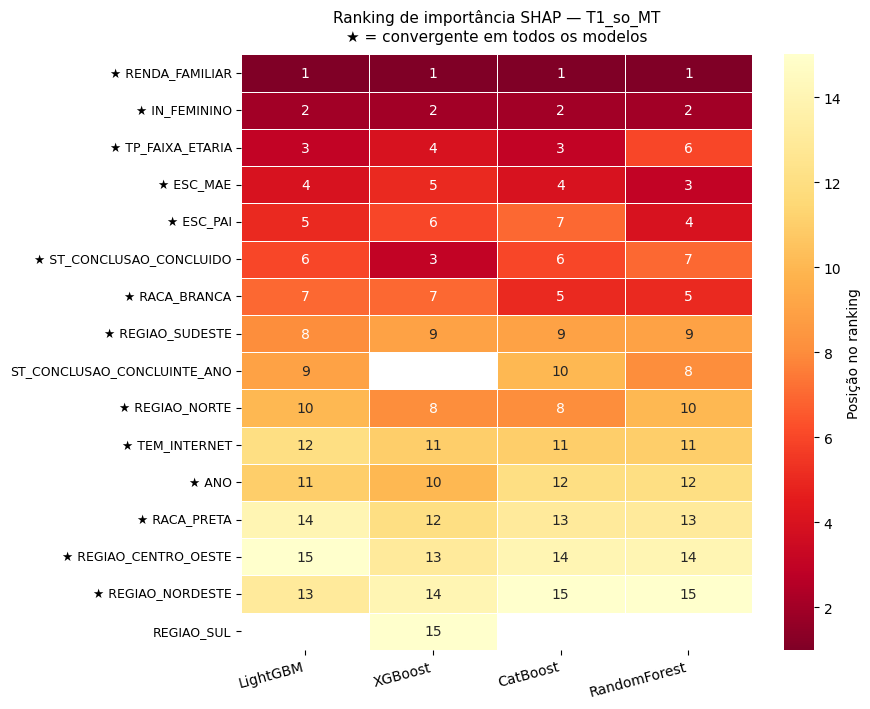

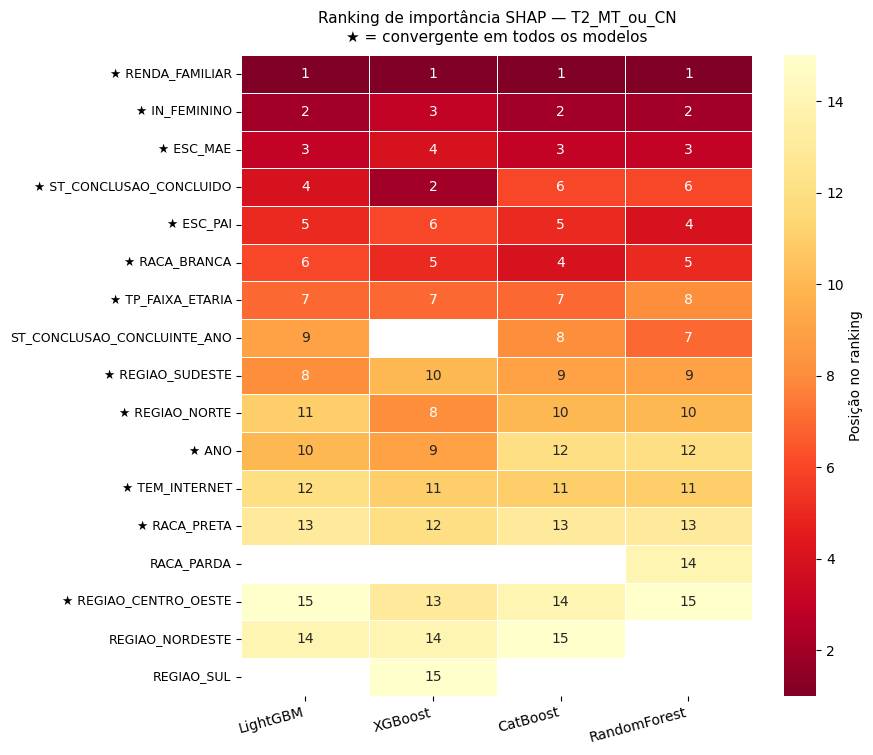

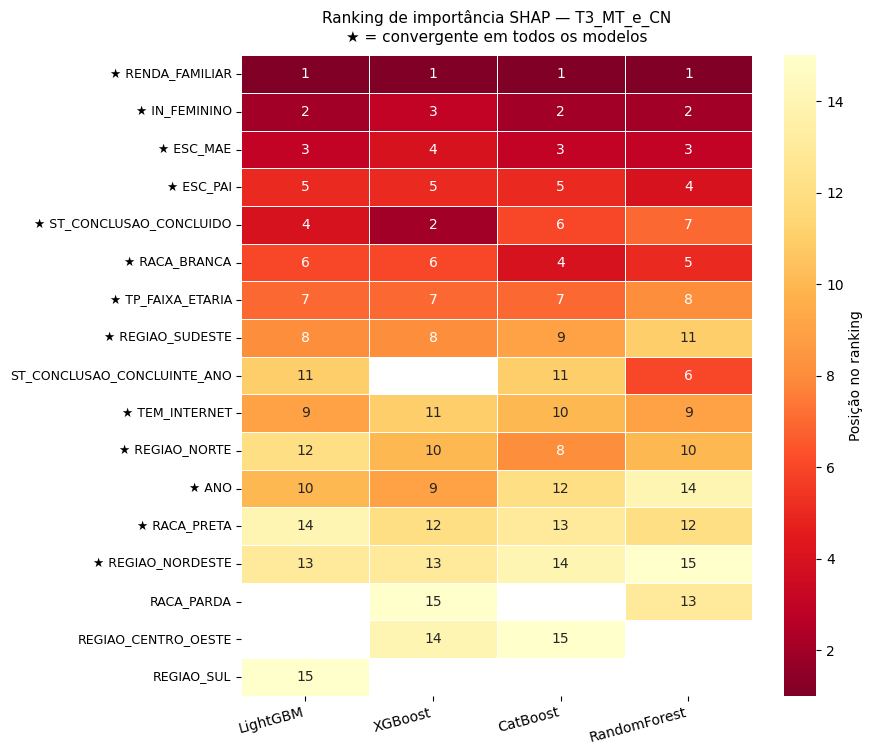

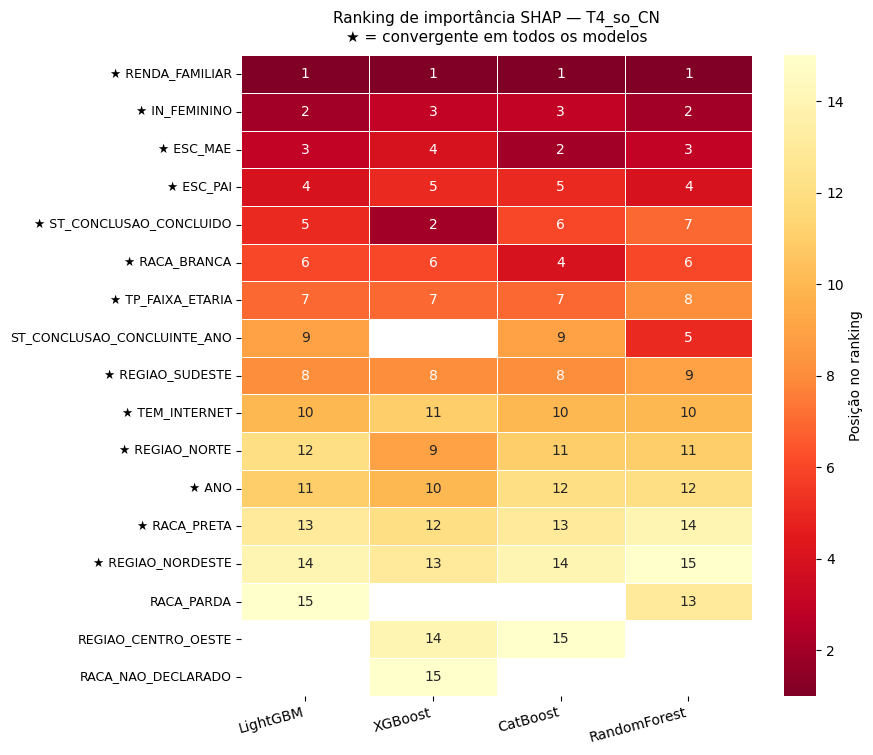

In [ ]:
# ── 10e. Gráfico de calor de convergência — ranking por feature e modelo ──────────────
# Cada célula = posição da feature no ranking de importância do modelo

for nome_t in TARGETS:
    # Pega todas as features que aparecem no top-15 de qualquer modelo
    todas_top = set()
    rankings  = {}
    
    for nome_m in TUNE_FNS_OPT:
        
        # Ignora modelos que falharam ou não têm dados SHAP
        if (nome_t, nome_m) not in shap_storage:
            continue
            
        sv = shap_storage[(nome_t, nome_m)]["shap_values"]
        Xe = shap_storage[(nome_t, nome_m)]["X"]
        
        # ─── CORREÇÃO DE FORMATO SHAP ────────────────────────────────────────
        if isinstance(sv, list):
            sv = sv[1] if len(sv) > 1 else sv[0]
        elif hasattr(sv, 'shape') and len(sv.shape) == 3:
            sv = sv[:, :, 1] if sv.shape[2] > 1 else sv[:, :, 0]
        # ─────────────────────────────────────────────────────────────────────
        
        mean_abs  = pd.Series(np.abs(sv).mean(axis=0), index=Xe.columns)
        rank_dict = {feat: i+1 for i, feat in enumerate(mean_abs.nlargest(TOP_N).index)}
        rankings[nome_m] = rank_dict
        todas_top |= set(rank_dict.keys())

    # Se nenhum modelo tiver dados, pula para o próximo target
    if not rankings:
        print(f"⚠️ Sem dados para plotar o heatmap de {nome_t}")
        continue

    # Monta matriz de rankings iterando apenas pelos modelos que funcionaram
    modelos_com_dados = list(rankings.keys())
    mat = pd.DataFrame(index=sorted(todas_top), columns=modelos_com_dados)
    
    for nome_m in modelos_com_dados:
        for feat in todas_top:
            mat.loc[feat, nome_m] = rankings[nome_m].get(feat, np.nan)
            
    mat = mat.astype(float)

    # Ordena por menor ranking médio (mais importante em geral)
    mat["media"] = mat.mean(axis=1)
    mat = mat.sort_values("media").drop(columns="media")

    # Marca features convergentes (Se convergencia_geral não existir, assume vazio)
    conv = convergencia_geral.get(nome_t, set())
    ytick_labels = [f"★ {f}" if f in conv else f for f in mat.index]

    # Dinamiza a altura do gráfico baseada na quantidade de features únicas
    fig, ax = plt.subplots(figsize=(9, max(6, len(mat)*0.45)))
    
    sns.heatmap(mat, annot=True, fmt=".0f", cmap="YlOrRd_r",
                linewidths=0.4, ax=ax, cbar_kws={"label": "Posição no ranking"},
                vmin=1, vmax=TOP_N)
                
    ax.set_title(f"Ranking de importância SHAP — {nome_t}\n★ = convergente em todos os modelos",
                 fontsize=11, pad=10)
    ax.set_yticklabels(ytick_labels, fontsize=9, rotation=0)
    ax.set_xticklabels(modelos_com_dados, rotation=15, ha="right")
    
    plt.tight_layout()
    
    os.makedirs("resultados", exist_ok=True)
    plt.savefig(f"resultados/08_shap_ranking_{nome_t}.png", dpi=130, bbox_inches="tight")
    
    plt.show()

Features convergentes em mais de um target
               Feature  N_targets                                     Targets
               ESC_PAI          4 T1_so_MT, T2_MT_ou_CN, T3_MT_e_CN, T4_so_CN
           IN_FEMININO          4 T1_so_MT, T2_MT_ou_CN, T3_MT_e_CN, T4_so_CN
           RACA_BRANCA          4 T1_so_MT, T2_MT_ou_CN, T3_MT_e_CN, T4_so_CN
ST_CONCLUSAO_CONCLUIDO          4 T1_so_MT, T2_MT_ou_CN, T3_MT_e_CN, T4_so_CN
          REGIAO_NORTE          4 T1_so_MT, T2_MT_ou_CN, T3_MT_e_CN, T4_so_CN
                   ANO          4 T1_so_MT, T2_MT_ou_CN, T3_MT_e_CN, T4_so_CN
        REGIAO_SUDESTE          4 T1_so_MT, T2_MT_ou_CN, T3_MT_e_CN, T4_so_CN
               ESC_MAE          4 T1_so_MT, T2_MT_ou_CN, T3_MT_e_CN, T4_so_CN
          TEM_INTERNET          4 T1_so_MT, T2_MT_ou_CN, T3_MT_e_CN, T4_so_CN
            RACA_PRETA          4 T1_so_MT, T2_MT_ou_CN, T3_MT_e_CN, T4_so_CN
        RENDA_FAMILIAR          4 T1_so_MT, T2_MT_ou_CN, T3_MT_e_CN, T4_so_CN
       TP_FAIXA_ETARI

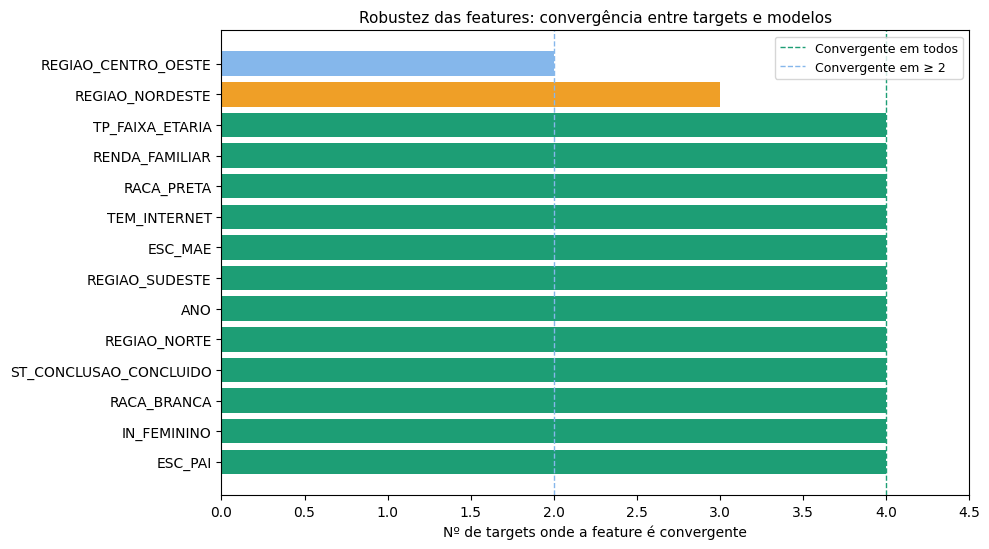

Salvo: resultados/convergencia_shap.csv


In [ ]:
# ── 10f. Comparação de convergência ENTRE targets ────────────────────────────
# Quais features são convergentes em múltiplos targets?

print("=" * 60)
print("Features convergentes em mais de um target")
print("=" * 60)

from collections import Counter
contagem = Counter()
for feats in convergencia_geral.values():
    contagem.update(feats)

df_conv = pd.DataFrame(contagem.most_common(), columns=["Feature", "N_targets"])
df_conv["Targets"] = df_conv["Feature"].apply(
    lambda f: ", ".join([t for t, feats in convergencia_geral.items() if f in feats])
)
print(df_conv.to_string(index=False))
df_conv.to_csv("resultados/convergencia_shap.csv", index=False)

# Visualização
fig, ax = plt.subplots(figsize=(10, max(4, len(df_conv)*0.4)))
cores_bar = ["#1D9E75" if n == 4 else "#EF9F27" if n == 3 else "#85B7EB" for n in df_conv["N_targets"]]
ax.barh(df_conv["Feature"], df_conv["N_targets"], color=cores_bar, edgecolor="none")
ax.set_xlabel("Nº de targets onde a feature é convergente")
ax.set_title("Robustez das features: convergência entre targets e modelos", fontsize=11)
ax.axvline(x=4, color="#1D9E75", linestyle="--", lw=1, label="Convergente em todos")
ax.axvline(x=2, color="#85B7EB", linestyle="--", lw=1, label="Convergente em ≥ 2")
ax.legend(fontsize=9); ax.set_xlim(0, 4.5)
plt.tight_layout()
plt.savefig("resultados/09_shap_convergencia_targets.png", dpi=150, bbox_inches="tight")
plt.show()
print("Salvo: resultados/convergencia_shap.csv")


## 11. SHAP Dependence plots — top features convergentes

Melhor combinação: T3_MT_e_CN + CatBoost  (AUC=0.7707)


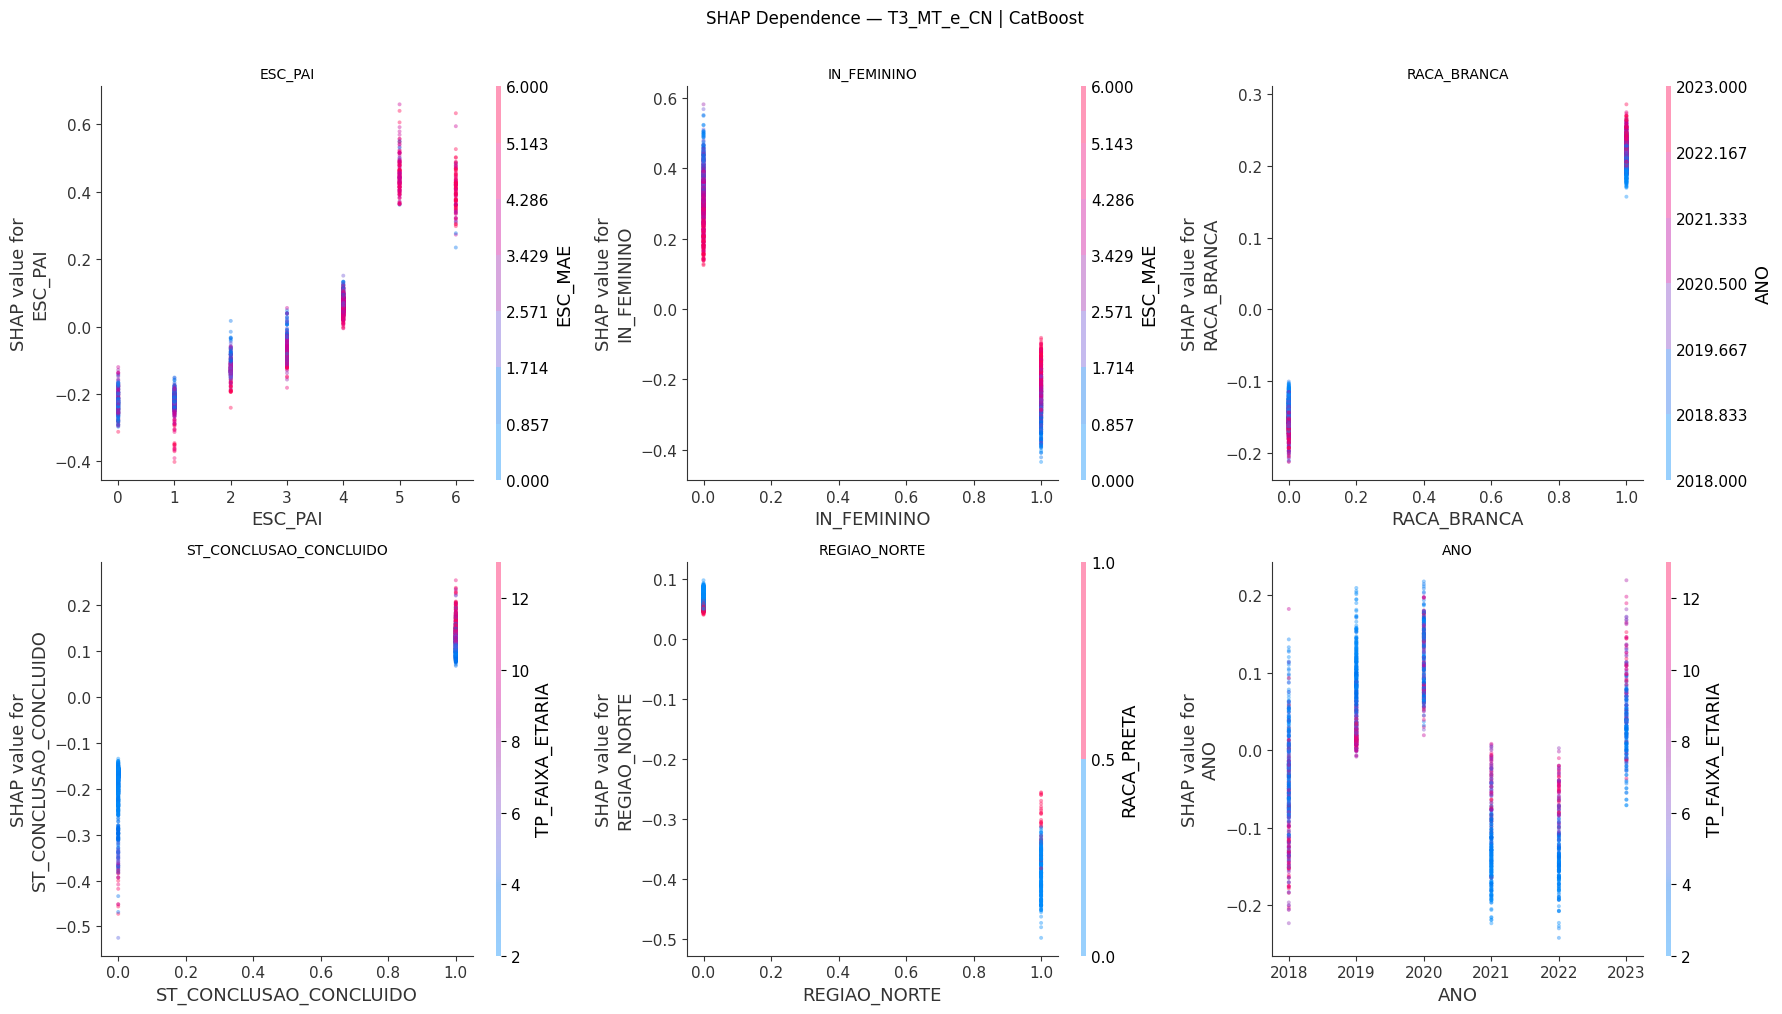

In [ ]:
# ── 11. Dependence plots para as features mais robustas ─────────────────────
# Escolhe o target e modelo com melhor AUC para plots de dependência detalhados

melhor_combo = df_comp.iloc[0]   # primeira linha = maior AUC_tuned
BEST_T = melhor_combo["Target"]
BEST_M = melhor_combo["Modelo"]

print(f"Melhor combinação: {BEST_T} + {BEST_M}  (AUC={melhor_combo['AUC_tuned']:.4f})")

sv = shap_storage[(BEST_T, BEST_M)]["shap_values"]
Xe = shap_storage[(BEST_T, BEST_M)]["X"]

# Top 6 features convergentes (ou top 6 gerais)
feats_plot = df_conv["Feature"].tolist()[:6] if len(df_conv) >= 6 else \
             list(pd.Series(np.abs(sv).mean(axis=0), index=Xe.columns).nlargest(6).index)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax, feat in zip(axes.flat, feats_plot):
    if feat not in Xe.columns:
        ax.axis("off"); continue
    shap.dependence_plot(feat, sv, Xe, ax=ax, show=False,
                         interaction_index="auto", dot_size=8, alpha=0.4)
    ax.set_title(feat, fontsize=10)

plt.suptitle(f"SHAP Dependence — {BEST_T} | {BEST_M}", fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig("resultados/10_shap_dependence.png", dpi=130, bbox_inches="tight")
plt.show()


## 13. Análise temporal — treinamento por ano

In [ ]:
import gc
import shap
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from catboost import CatBoostClassifier

# ── 13a. Loop por ano — Apenas CatBoost no target MT_e_CN ───────────────────

# ─── DEFINIÇÃO DO X (FEATURES) ──────────────────────────────────────────────
colunas_para_remover = ["T1_so_MT", "T2_CN", "T3_MT_e_CN", "ANO", "NU_INSCRICAO", "NU_NOTA_MT", "NU_NOTA_CN", "MED_MT", "MED_CN"] 
colunas_presentes = [c for c in colunas_para_remover if c in df.columns]
X = df.drop(columns=colunas_presentes)
# ────────────────────────────────────────────────────────────────────────────

ANOS = sorted(df["ANO"].unique())
MODELOS_TEMPORAIS = ["CatBoost"]
N_SHAP = 500 # Adicionado caso a variável tenha se perdido no reinício

# Estruturas de armazenamento
shap_por_ano = {m: {} for m in MODELOS_TEMPORAIS}   # shap values por ano
pred_por_ano = {m: {} for m in MODELOS_TEMPORAIS}   # y_test / y_pred por ano

# Target definido
TARGET_TEMPORAL = "T3_MT_e_CN"
y_temporal = TARGETS[TARGET_TEMPORAL]

print(f"Target temporal: {TARGET_TEMPORAL}")
print(f"Anos: {ANOS}\n")

# Tenta puxar os parâmetros tunados (se não achar, usa dicionário vazio)
best_p = melhores_params.get((TARGET_TEMPORAL, "CatBoost"), {})

for ano in ANOS:
    mask = df["ANO"] == ano
    X_ano = X[mask]
    y_ano = y_temporal[mask]

    X_tr, X_te, y_tr, y_te = train_test_split(
        X_ano, y_ano, test_size=0.2, random_state=42, stratify=y_ano
    )

    print(f"  {ano}  ({len(X_ano):,} alunos) ", end="")

    # Instancia o CatBoost com os parâmetros do Tuning e limite de RAM
    modelo = CatBoostClassifier(
        **best_p,
        auto_class_weights="Balanced",
        cat_features=CAT_IDX if 'CAT_IDX' in globals() and CAT_IDX else None,
        thread_count=2, # Previne o erro "bad allocation"
        random_seed=42,
        verbose=0
    )

    # Treina o modelo para o ano específico
    modelo.fit(X_tr, y_tr, eval_set=(X_te, y_te), verbose=False, early_stopping_rounds=20)
    
    y_pred  = modelo.predict(X_te)
    y_proba = modelo.predict_proba(X_te)[:, 1]

    pred_por_ano["CatBoost"][ano] = {
        "y_test": y_te, "y_pred": y_pred, "y_proba": y_proba,
        "auc": roc_auc_score(y_te, y_proba),
    }

    # SHAP por ano (amostra para velocidade)
    X_explain = X_te.sample(min(N_SHAP, len(X_te)), random_state=42)

    expl = shap.TreeExplainer(modelo)
    sv = expl.shap_values(X_explain)

    if isinstance(sv, list):
        sv = sv[1] if len(sv) > 1 else sv[0]
    elif hasattr(sv, 'shape') and len(sv.shape) == 3:
        sv = sv[:, :, 1] if sv.shape[2] > 1 else sv[:, :, 0]

    shap_por_ano["CatBoost"][ano] = {"shap_values": sv, "X": X_explain}
    print(f"[CatBoost OK]", flush=True)

    del mask, X_ano, y_ano, X_tr, X_te, y_tr, y_te, expl, sv
    gc.collect()

print("\nLoop temporal concluído com sucesso!")

Target temporal: T3_MT_e_CN
Anos: [np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023)]



NameError: name 'melhores_params' is not defined

### Imagem 1 — Evolução da importância das variáveis ao longo dos anos (CatBoost)

NameError: name 'ANOS' is not defined

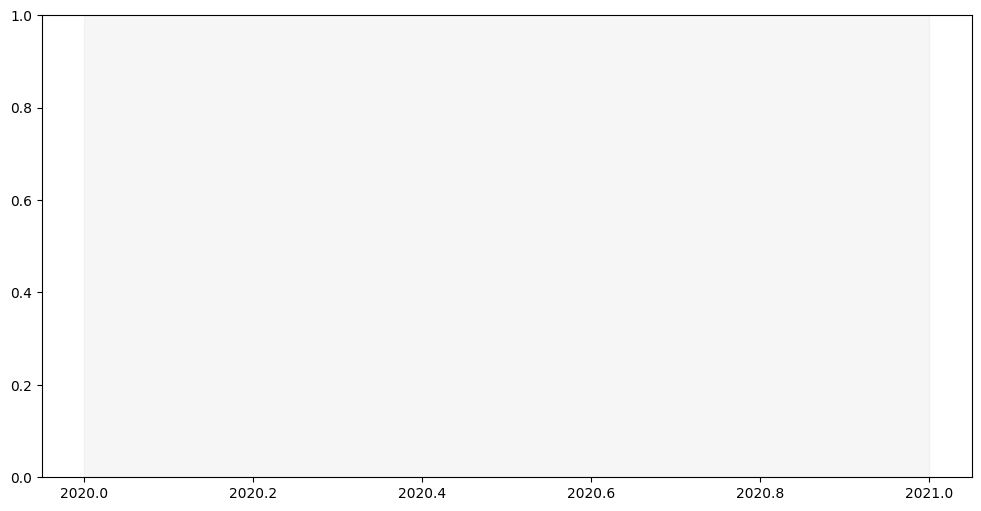

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ── 13b. Evolução temporal da importância (Adaptado para SHAP do CatBoost) ──

FEATURES_DESTAQUE = [
    "RENDA_FAMILIAR",
    "ESC_PAI",
    "ESC_MAE",
    "IN_FEMININO",
]

ESTILOS = {
    "RENDA_FAMILIAR":  {"color": "#1A6FA8", "linestyle": "--", "marker": "o", "label": "Renda Familiar"},
    "ESC_PAI":         {"color": "#5DCAA5", "linestyle": "--", "marker": "o", "label": "Escolaridade do Pai"},
    "ESC_MAE":         {"color": "#888780", "linestyle": "--", "marker": "o", "label": "Escolaridade da Mãe"},
    "IN_FEMININO":     {"color": "#862081", "linestyle": "-",  "marker": "o", "label": "Gênero (IN_FEMININO)"},
}

fig, ax = plt.subplots(figsize=(12, 6))

# Faixa de pandemia
ax.axvspan(2020, 2021, alpha=0.07, color="gray", label="Pandemia COVID-19")

for feat, estilo in ESTILOS.items():
    valores = []
    for ano in ANOS:
        # Puxa os dados SHAP do CatBoost salvos no passo anterior
        shap_data = shap_por_ano["CatBoost"].get(ano)
        
        if shap_data is not None:
            sv = shap_data["shap_values"]
            Xe = shap_data["X"]
            # Calcula a importância média (|SHAP|) para todas as features naquele ano
            mean_abs = pd.Series(np.abs(sv).mean(axis=0), index=Xe.columns)
            # Pega o valor específico da feature que estamos analisando
            valor_feat = mean_abs.get(feat, np.nan)
        else:
            valor_feat = np.nan
            
        valores.append(valor_feat)

    # Plota a linha da feature
    ax.plot(ANOS, valores, **estilo, linewidth=2, markersize=6)

    # Anotações dos valores numéricos na linha (apenas IN_FEMININO)
    if feat == "IN_FEMININO":
        for ano, v in zip(ANOS, valores):
            if not np.isnan(v):
                ax.annotate(f"{v:.3f}", xy=(ano, v), xytext=(0, 8),
                            textcoords="offset points", ha="center",
                            fontsize=8, color=estilo["color"])

ax.set_xticks(ANOS)
ax.set_xlabel("Ano", fontsize=11)
ax.set_ylabel("Impacto Médio (|SHAP|)", fontsize=11) # Eixo renomeado para refletir o SHAP
ax.set_title(
    f"Importância das variáveis no perfil STEM ({ANOS[0]}–{ANOS[-1]})\nCatBoost (SHAP) — ENEM",
    fontsize=13, fontweight="bold"
)
ax.legend(loc="upper right", fontsize=9, framealpha=0.9)
ax.grid(axis="y", linestyle="--", alpha=0.5)
ax.set_ylim(bottom=0)

plt.tight_layout()

# Salva na pasta (garantindo que ela existe)
import os
os.makedirs("resultados", exist_ok=True)
plt.savefig("resultados/11_evolucao_importancia_catboost.png", dpi=150, bbox_inches="tight")

plt.show()
print("Salvo: resultados/11_evolucao_importancia_catboost.png")



### Imagem 2 — Matrizes de confusão por ano e modelo

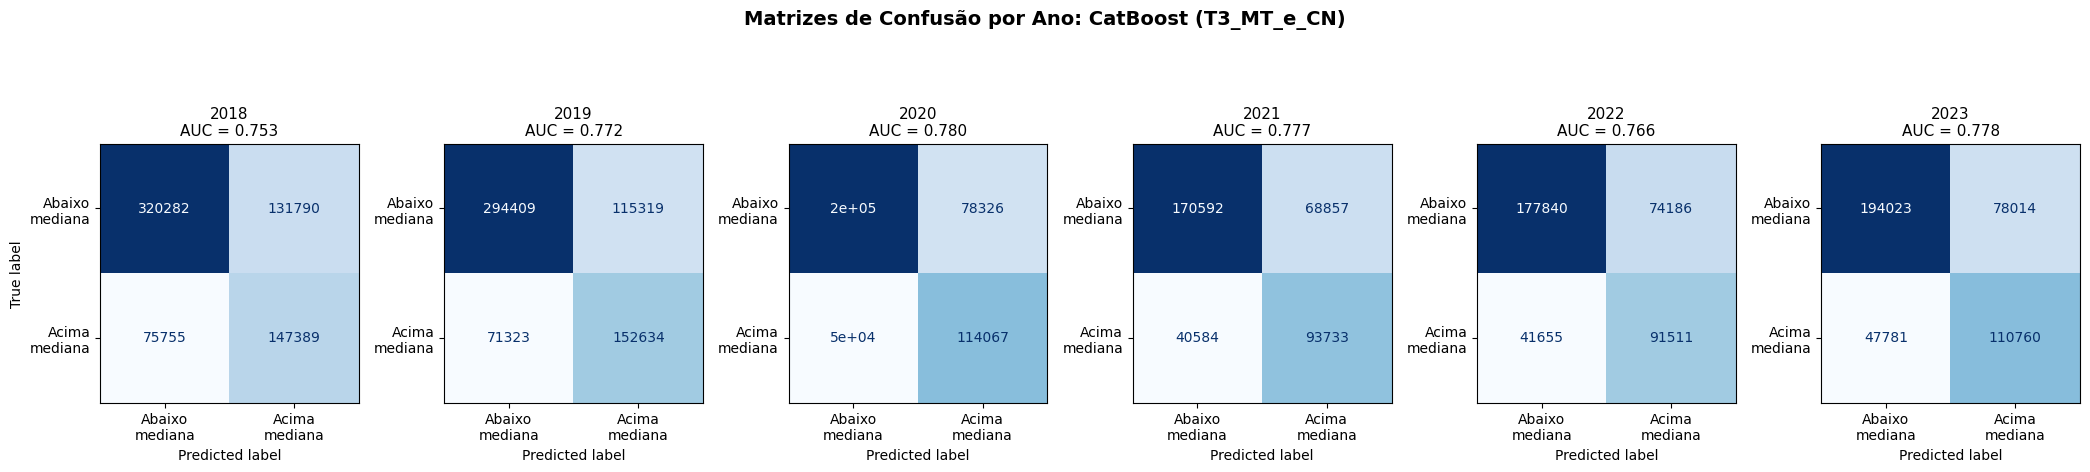

✅ Salvo: resultados/12_confusao_por_ano_catboost.png


In [ ]:
import os
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# ── 13c. Matrizes de confusão por ano — Apenas CatBoost ───────────────────
# Uma única linha (CatBoost), uma coluna por ano

nome_m = "CatBoost"

fig, axes = plt.subplots(
    1, len(ANOS),
    figsize=(len(ANOS) * 3.5, 4.5) # Altura ajustada para 1 única linha
)

# Trava de segurança: garante que axes seja uma lista mesmo se houver apenas 1 ano
if len(ANOS) == 1:
    axes = [axes]

for col, ano in enumerate(ANOS):
    ax = axes[col]
    
    # Busca os dados salvos do CatBoost no ano específico
    info = pred_por_ano[nome_m][ano]
    
    ConfusionMatrixDisplay.from_predictions(
        info["y_test"], info["y_pred"],
        display_labels=["Abaixo\nmediana", "Acima\nmediana"],
        cmap="Blues", ax=ax, colorbar=False,
    )
    
    # Título do subplot agora foca só no Ano e no AUC
    ax.set_title(f"{ano}\nAUC = {info['auc']:.3f}", fontsize=11)
    
    # Remove a legenda "True label" dos eixos Y a partir do segundo ano para não poluir
    if col > 0:
        ax.set_ylabel("")

plt.suptitle(f"Matrizes de Confusão por Ano: CatBoost ({TARGET_TEMPORAL})",
             fontsize=14, fontweight="bold", y=1.05)

plt.tight_layout()

# Segurança para garantir que a pasta existe antes de salvar
os.makedirs("resultados", exist_ok=True)
plt.savefig("resultados/12_confusao_por_ano_catboost.png", dpi=130, bbox_inches="tight")

plt.show()
print("✅ Salvo: resultados/12_confusao_por_ano_catboost.png")


### Imagens 3 e 4 — SHAP bar e beeswarm por ano e modelo

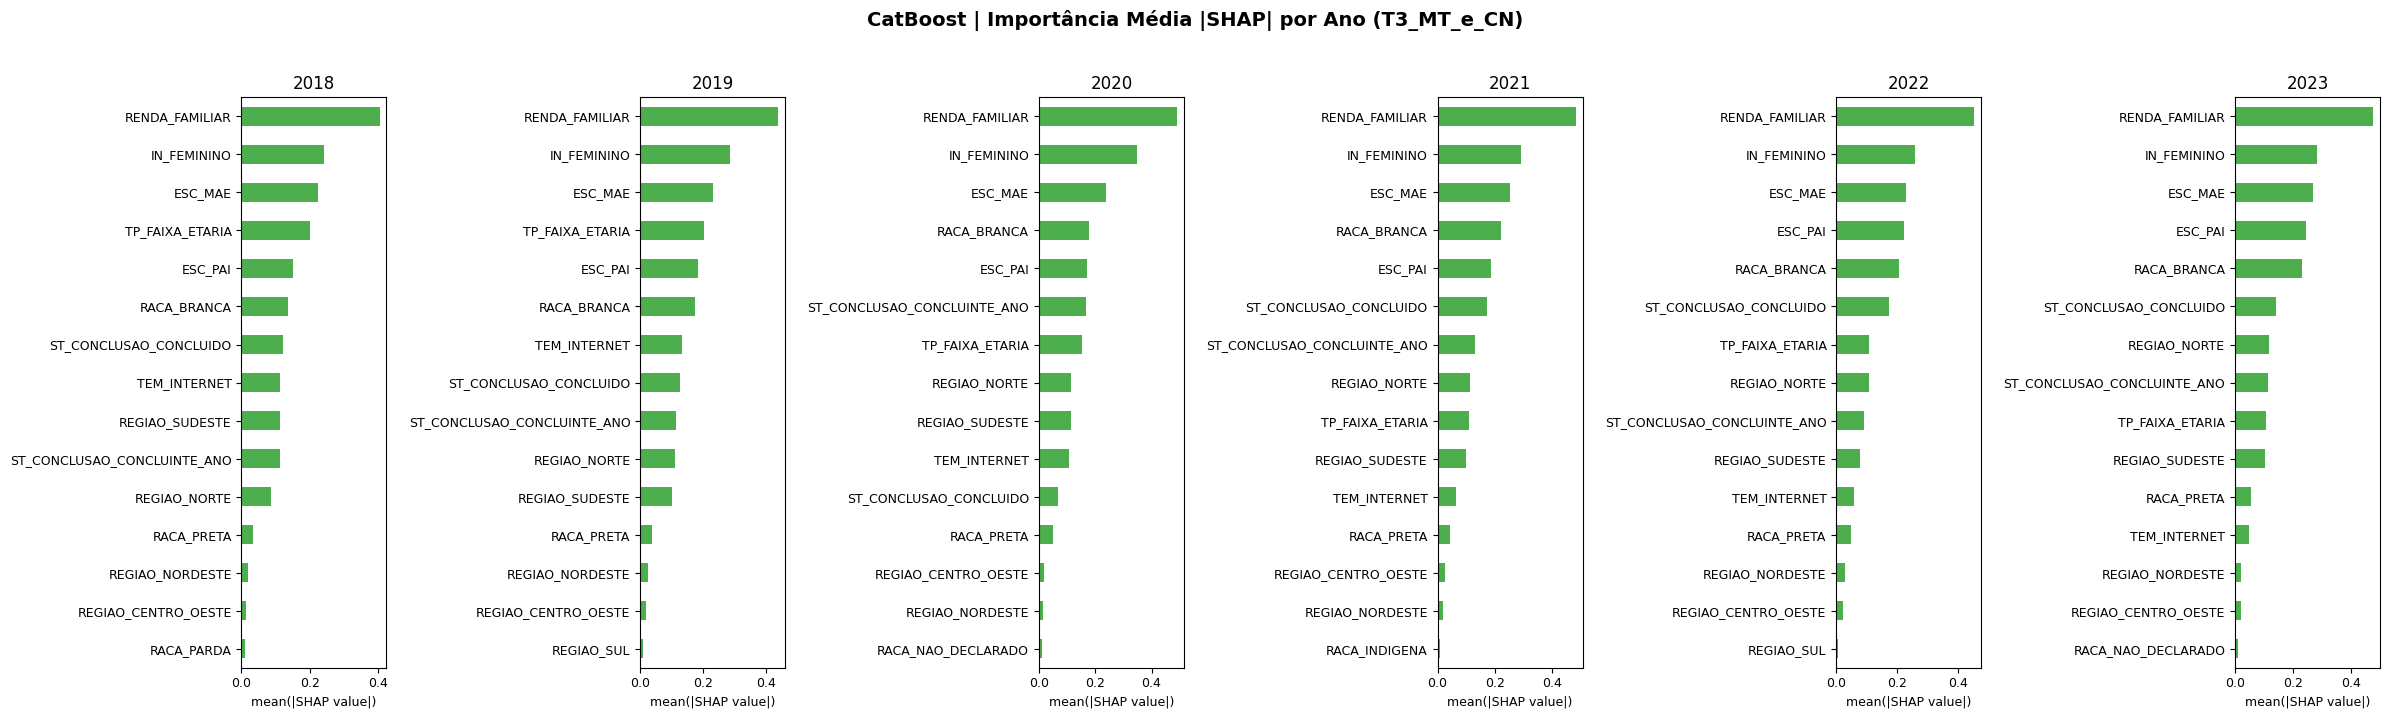

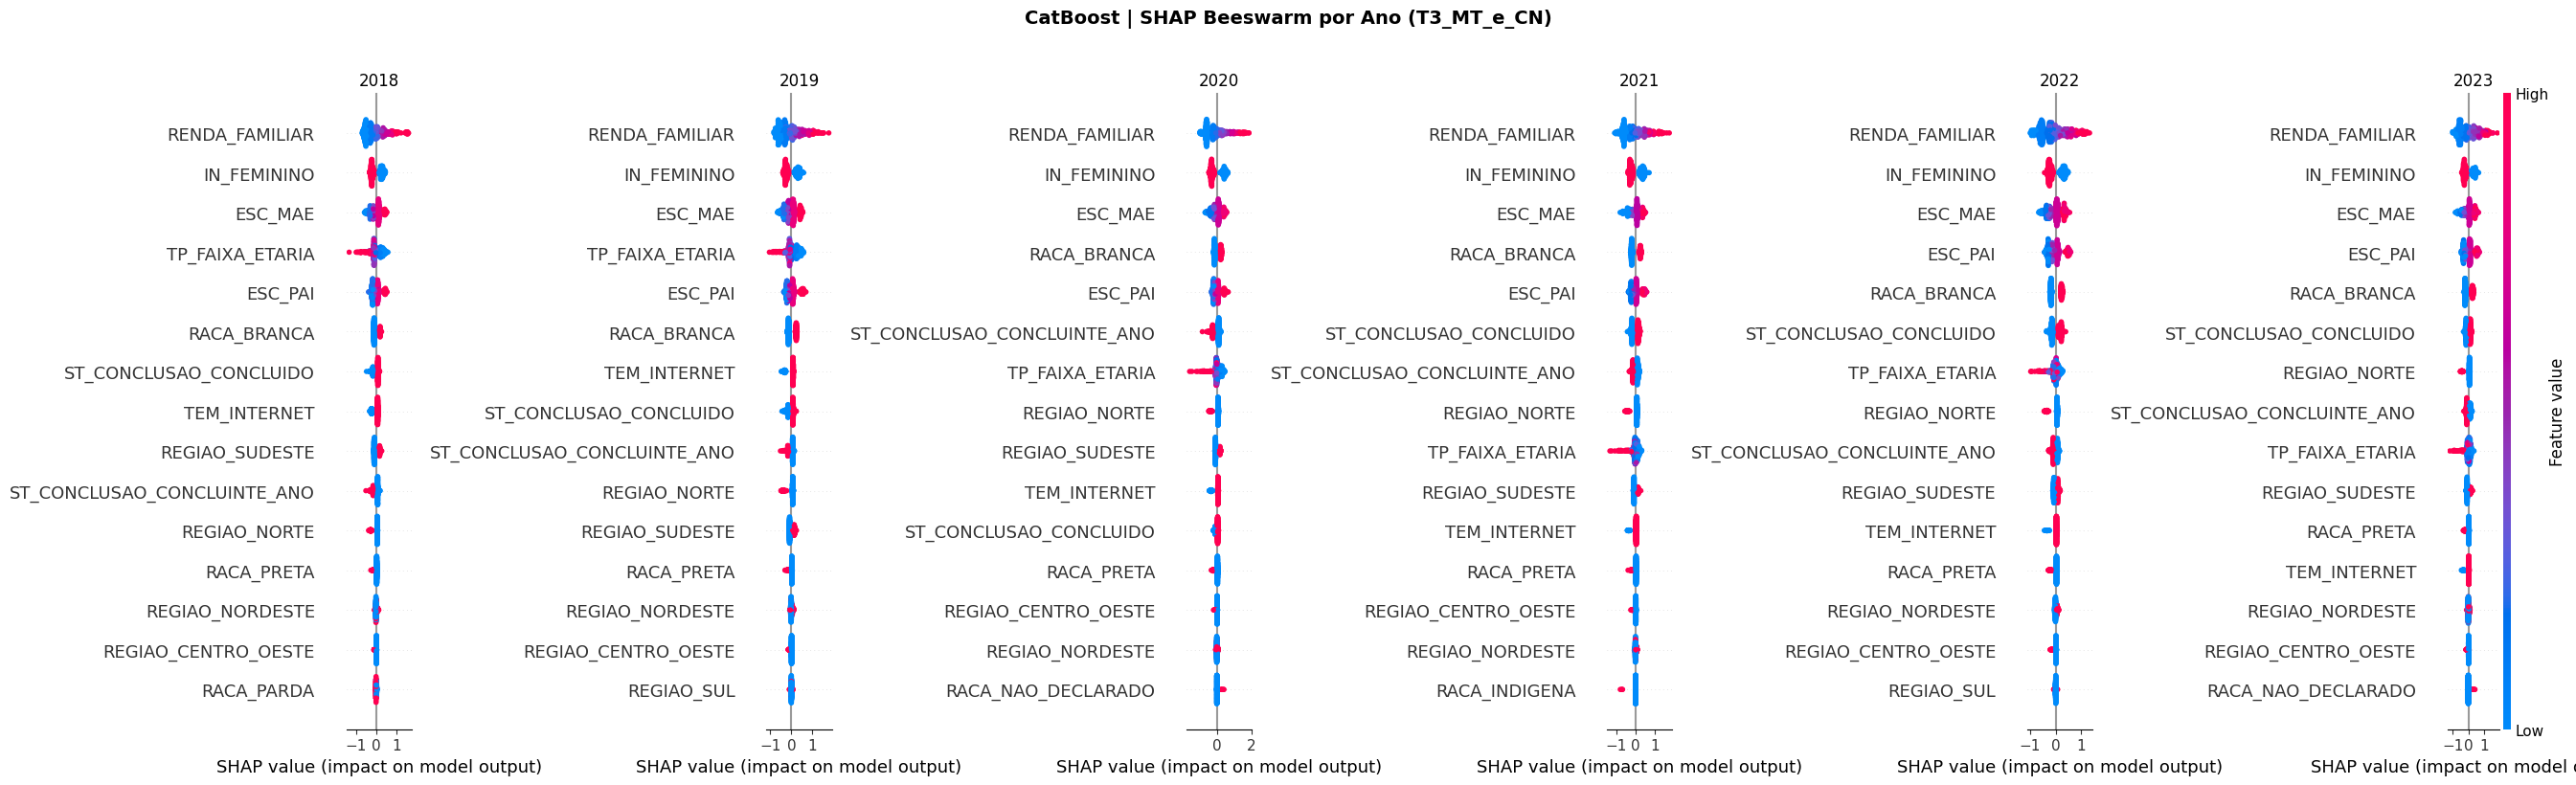

✅ Salvos:
 - resultados/13_shap_bar_CatBoost.png
 - resultados/14_shap_beeswarm_CatBoost.png


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

# Segurança para a cor (caso a variável CORES original tenha se perdido na RAM)
cores_seguras = {"CatBoost": "#2ca02c"} # Verde padrão para o CatBoost
CORES_ATIVAS = globals().get('CORES', cores_seguras)

nome_m = "CatBoost"

# ── 13d. SHAP bar e beeswarm por ano — Apenas CatBoost ──────────────────────

# ── 1. Bar plot: Importância média absoluta por ano ─────────────────────────
fig, axes = plt.subplots(1, len(ANOS), figsize=(len(ANOS) * 4, 7), sharey=False)
fig.suptitle(f"{nome_m} | Importância Média |SHAP| por Ano ({TARGET_TEMPORAL})",
             fontsize=14, fontweight="bold", y=1.02)

# Trava de segurança para iteração no matplotlib
if len(ANOS) == 1:
    axes = [axes]

for ax, ano in zip(axes, ANOS):
    info = shap_por_ano[nome_m][ano]
    sv   = info["shap_values"]
    Xe   = info["X"]
    
    mean_abs = pd.Series(np.abs(sv).mean(axis=0), index=Xe.columns).nlargest(15).sort_values()
    cor = CORES_ATIVAS.get(nome_m, "#2ca02c")
    
    mean_abs.plot(kind="barh", ax=ax, color=cor, alpha=0.85, edgecolor="none")
    ax.set_title(str(ano), fontsize=12)
    ax.set_xlabel("mean(|SHAP value|)", fontsize=9)
    ax.tick_params(labelsize=9)

plt.tight_layout()

# Cria a pasta caso não exista
os.makedirs("resultados", exist_ok=True)
plt.savefig(f"resultados/13_shap_bar_{nome_m}.png", dpi=130, bbox_inches="tight")
plt.show()


# ── 2. Beeswarm: Distribuição do impacto por ano ────────────────────────────
fig, axes = plt.subplots(1, len(ANOS), figsize=(len(ANOS) * 4.5, 8))
fig.suptitle(f"{nome_m} | SHAP Beeswarm por Ano ({TARGET_TEMPORAL})",
             fontsize=14, fontweight="bold", y=1.02)

if len(ANOS) == 1:
    axes = [axes]

for ax, ano in zip(axes, ANOS):
    info = shap_por_ano[nome_m][ano]
    
    plt.sca(ax)
    shap.summary_plot(
        info["shap_values"], info["X"],
        max_display=15, show=False, plot_size=None,
        color_bar=(ano == ANOS[-1]),   # barra de cor só aparece no último ano
    )
    ax.set_title(str(ano), fontsize=12)

plt.tight_layout()
plt.savefig(f"resultados/14_shap_beeswarm_{nome_m}.png", dpi=130, bbox_inches="tight")
plt.show()

print(f"✅ Salvos:\n - resultados/13_shap_bar_{nome_m}.png\n - resultados/14_shap_beeswarm_{nome_m}.png")


### Imagem 5 — Convergência SHAP de uma feature específica ao longo dos anos

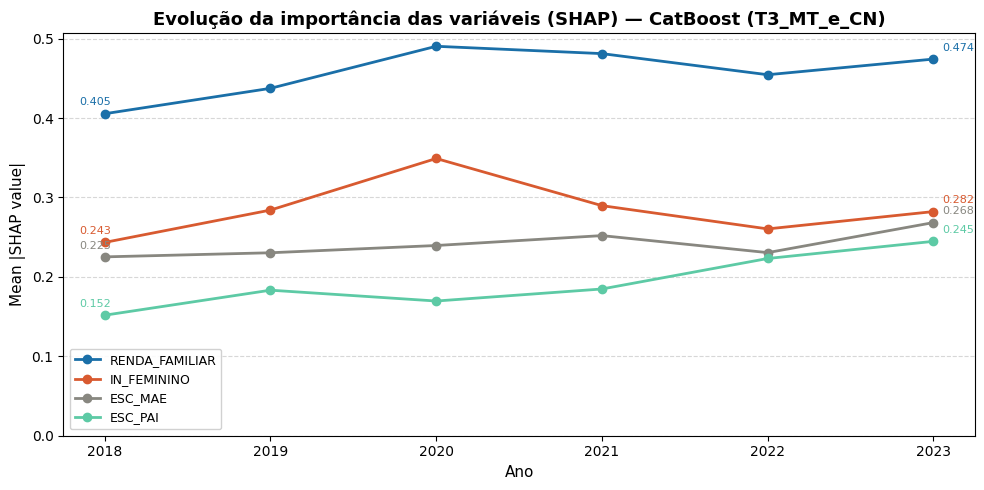

✅ Salvo: resultados/16_shap_evolucao_features_CatBoost.png


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ── 13e. Convergência temporal SHAP (Focado apenas no CatBoost) ───────────────

# --- NOTA ---
# A primeira parte do seu script original comparava modelos diferentes (XGB vs LGBM vs CatBoost).
# Como agora temos apenas dados do CatBoost, pulei diretamente para o gráfico "Multi-Feature",
# que compara variáveis dentro do mesmo modelo (CatBoost).
# ------------

# ── Versão multi-feature: evolução das features ao longo dos anos ────────────
FEATURES_CONV = ["RENDA_FAMILIAR", "IN_FEMININO", "ESC_MAE", "ESC_PAI"]
CORES_FEAT    = {
    "RENDA_FAMILIAR": "#1A6FA8", # Azul
    "IN_FEMININO":    "#D85A30", # Laranja/Vermelho
    "ESC_MAE":        "#888780", # Cinza
    "ESC_PAI":        "#5DCAA5", # Verde água
}
MODELO_REF = "CatBoost"  # <-- MUDANÇA AQUI: de XGBoost para CatBoost

fig, ax = plt.subplots(figsize=(10, 5))

for feat in FEATURES_CONV:
    vals = []
    for ano in ANOS:
        info = shap_por_ano[MODELO_REF].get(ano)
        
        # Se não houver dados para o ano, adiciona NaN e pula
        if info is None or feat not in info["X"].columns:
            vals.append(np.nan)
            continue
            
        sv = info["shap_values"]
        Xe = info["X"]
        
        idx = list(Xe.columns).index(feat)
        
        # Pega a média absoluta do SHAP daquela feature (garantindo que sv já é 2D)
        val_shap = np.abs(sv[:, idx]).mean()
        vals.append(val_shap)
        
    ax.plot(ANOS, vals, marker="o", linewidth=2, markersize=6,
            color=CORES_FEAT[feat], label=feat)

    # Anotações no primeiro e último ponto (para facilitar a leitura)
    for i, ano in enumerate([ANOS[0], ANOS[-1]]):
        v = vals[ANOS.index(ano)]
        if not np.isnan(v):
            offset = (-18, 6) if ano == ANOS[0] else (6, 6)
            ax.annotate(f"{v:.3f}", xy=(ano, v), xytext=offset,
                        textcoords="offset points", fontsize=8,
                        color=CORES_FEAT[feat])

ax.set_xticks(ANOS)
ax.set_xlabel("Ano", fontsize=11)
ax.set_ylabel("Mean |SHAP value|", fontsize=11)
ax.set_title(
    f"Evolução da importância das variáveis (SHAP) — {MODELO_REF} ({TARGET_TEMPORAL})",
    fontsize=13, fontweight="bold"
)
ax.legend(fontsize=9, framealpha=0.9, loc="best")
ax.grid(axis="y", linestyle="--", alpha=0.5)
ax.set_ylim(bottom=0)

plt.tight_layout()

# Segurança para a pasta de saída
os.makedirs("resultados", exist_ok=True)
plt.savefig(f"resultados/16_shap_evolucao_features_{MODELO_REF}.png", dpi=150, bbox_inches="tight")

plt.show()
print(f"✅ Salvo: resultados/16_shap_evolucao_features_{MODELO_REF}.png")


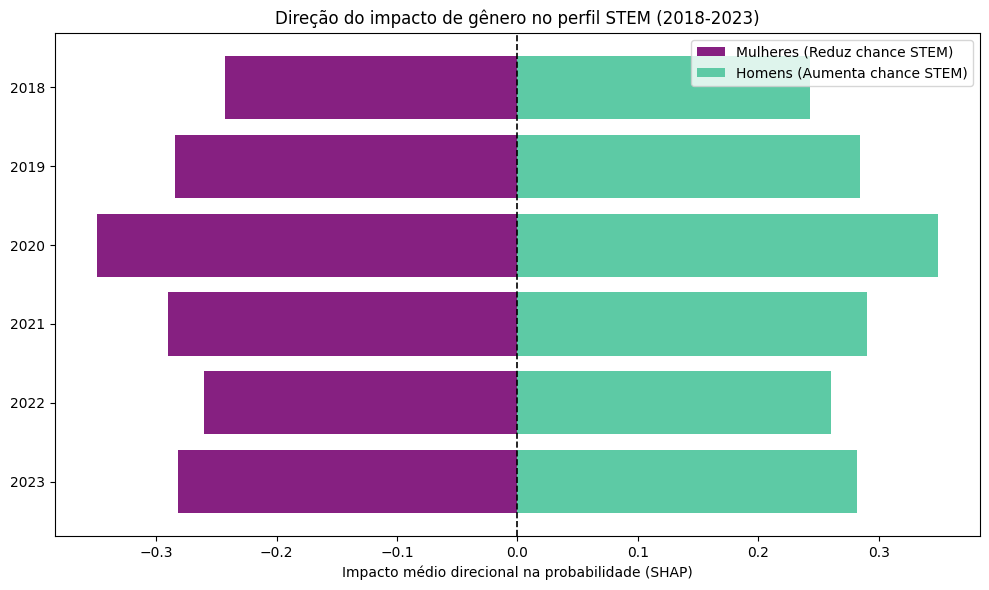

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Anos no escopo
anos = ['2018', '2019', '2020', '2021', '2022', '2023']

# Coloque os valores negativos que saíram no print (media_fem)
impacto_mulheres = [-0.243, -0.284, -0.349, -0.290, -0.260, -0.282] 

# Coloque os valores positivos que saíram no print (media_masc)
impacto_homens = [0.243, 0.284, 0.349, 0.290, 0.260, 0.282] 

# 2. Configuração do Gráfico
fig, ax = plt.subplots(figsize=(10, 6))

y_pos = np.arange(len(anos))

# Barras horizontais
ax.barh(y_pos, impacto_mulheres, align='center', color='#862081', label='Mulheres (Reduz chance STEM)')
ax.barh(y_pos, impacto_homens, align='center', color='#5DCAA5', label='Homens (Aumenta chance STEM)')

# Formatação visual
ax.set_yticks(y_pos)
ax.set_yticklabels(anos)
ax.invert_yaxis()  # Anos mais antigos no topo
ax.set_xlabel('Impacto médio direcional na probabilidade (SHAP)')
ax.set_title('Direção do impacto de gênero no perfil STEM (2018-2023)')

# Desenhando a linha do zero (Neutralidade)
ax.axvline(0, color='black', linewidth=1.2, linestyle='--')
ax.legend()

plt.tight_layout()
plt.show()

In [ ]:
# ── 10. Gráfico de impacto de gênero  ────────────

def plotar_impacto_genero_shap(X_test, valores_shap, nome_coluna_genero='IN_FEMININO', nome_coluna_ano='ANO'):
    """
    Calcula dinamicamente a média do impacto SHAP da variável de gênero e 
    plota um gráfico de barras divergentes (Homens vs Mulheres) ao longo dos anos.

    Args:
        X_test (pd.DataFrame): DataFrame de teste contendo as colunas de Ano e Gênero originais.
        valores_shap (np.ndarray): Matriz bidimensional com os valores SHAP do modelo. 
            Deve ter o mesmo número de linhas que o X_test.
        nome_coluna_genero (str): Nome da coluna binária de gênero no dataset (1=Feminino, 0=Masculino).
        nome_coluna_ano (str): Nome da coluna que indica o ano da prova.
    """
    
    #  Identifica os anos únicos diretamente do dataset e ordenar
    anos_unicos = sorted(X_test[nome_coluna_ano].unique())
    anos_str = [str(ano) for ano in anos_unicos] # Converte para string para os rótulos do eixo Y
    
    # Descobre o índice (posição da coluna) da variável de gênero dentro da matriz SHAP
    idx_genero = X_test.columns.get_loc(nome_coluna_genero)

    # Listas vazias que serão preenchidas automaticamente pelo loop
    impacto_mulheres = []
    impacto_homens   = []

    print("📊 Calculando médias de SHAP por ano e gênero...")

    # Loop de Extração Dinâmica de Dados
    for ano in anos_unicos:
        # Cria uma máscara booleana para filtrar as linhas apenas do ano atual
        mask_ano = X_test[nome_coluna_ano] == ano
        
        # Pega a coluna exata do SHAP de Gênero, apenas para os candidatos deste ano
        shap_genero_ano = valores_shap[mask_ano, idx_genero]
        
        # Pega a coluna real de Gênero (0 ou 1) do dataset, apenas para este ano
        genero_real_ano = X_test.loc[mask_ano, nome_coluna_genero]
        
        # Separa os valores SHAP entre Mulheres (1) e Homens (0)
        shap_fem = shap_genero_ano[genero_real_ano == 1]
        shap_masc = shap_genero_ano[genero_real_ano == 0]
        
        # Calcula a média do impacto para cada grupo e adiciona na lista final
        # Se por acaso algum ano não tiver um dos gêneros (improvável), usa 0 via np.mean() guardado contra NaN
        media_fem = np.mean(shap_fem) if len(shap_fem) > 0 else 0
        media_masc = np.mean(shap_masc) if len(shap_masc) > 0 else 0
        
        impacto_mulheres.append(media_fem)
        impacto_homens.append(media_masc)

    # Configuração e Construção do Gráfico
    fig, ax = plt.subplots(figsize=(10, 6))

    # Posições no eixo Y baseadas na quantidade de anos processados
    y_pos = np.arange(len(anos_unicos))

    # Plota as barras divergentes com as listas dinâmicas recém-criadas
    ax.barh(y_pos, impacto_mulheres, align='center', color='#862081', label='Mulheres (Reduz chance STEM)')
    ax.barh(y_pos, impacto_homens,   align='center', color='#5DCAA5', label='Homens (Aumenta chance STEM)')

    # Formatação do Eixo Y (Posições, Rótulos e Inversão para o mais antigo ficar no topo)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(anos_str)
    ax.invert_yaxis()  
    
    # Textos e Títulos
    ax.set_xlabel('Impacto médio direcional na probabilidade (SHAP)', fontsize=11)
    ax.set_title('Direção do impacto de gênero no perfil STEM', fontsize=13, pad=15)

    # Adiciona a linha preta tracejada central marcando o zero (Ponto de Neutralidade)
    ax.axvline(0, color='black', linewidth=1.2, linestyle='--')
    
    # Posiciona a legenda fora da área de colisão (opcionalmente pode ser 'best')
    ax.legend(loc='lower right')

    # Ajusta o layout para impedir cortes ao salvar/exibir
    plt.tight_layout()
    
    # Salva o gráfico e mostra
    plt.savefig("resultados/grafico_impacto_genero.png", dpi=150, bbox_inches="tight")
    plt.show()

plotar_impacto_genero_shap(X_test, valores_shap, nome_coluna_genero='IN_FEMININO', nome_coluna_ano='ANO')

### Sumário dos arquivos de saída

In [ ]:
# ── Sumário completo de arquivos gerados ────────────────────────────────────
print("\n╔" + "═"*60 + "╗")
print("║  ARQUIVOS GERADOS EM /resultados/".ljust(62) + "║")
print("╠" + "═"*60 + "╣")
for arq in sorted(os.listdir("resultados")):
    tamanho = os.path.getsize(f"resultados/{arq}") / 1024
    print(f"║  {arq:<40} {tamanho:>7.1f} KB  ║")
print("╚" + "═"*60 + "╝")



╔════════════════════════════════════════════════════════════╗
║  ARQUIVOS GERADOS EM /resultados/                           ║
╠════════════════════════════════════════════════════════════╣
║  01_heatmap_baseline.png                     89.3 KB  ║
║  02_roc_baseline.png                        147.8 KB  ║
║  03_heatmap_comparativo.png                  97.4 KB  ║
║  04_roc_tuned.png                           153.6 KB  ║
║  05_matrizes_confusao.png                    71.7 KB  ║
║  06_shap_beeswarm_T1_so_MT.png               85.3 KB  ║
║  06_shap_beeswarm_T2_MT_ou_CN.png            87.0 KB  ║
║  06_shap_beeswarm_T3_MT_e_CN.png             76.6 KB  ║
║  06_shap_beeswarm_T4_so_CN.png               88.8 KB  ║
║  07_shap_bar_T1_so_MT.png                    84.8 KB  ║
║  07_shap_bar_T2_MT_ou_CN.png                 86.7 KB  ║
║  07_shap_bar_T3_MT_e_CN.png                  86.4 KB  ║
║  07_shap_bar_T4_so_CN.png                    85.0 KB  ║
║  08_shap_ranking_T1_so_MT.png                83.6 KB 

## 12. Sumário final

In [ ]:
# ── 12. Sumário final ────────────────────────────────────────────────────────
print("╔" + "═"*58 + "╗")
print("║  SUMÁRIO FINAL DO PIPELINE".ljust(59) + "║")
print("╠" + "═"*58 + "╣")

print("║  Melhor combinação (AUC):".ljust(59) + "║")
for _, row in df_comp.head(5).iterrows():
    linha = f"    {row['Target']} + {row['Modelo']}  →  AUC={row['AUC_tuned']:.4f}"
    print(f"║  {linha:<57}║")

print("╠" + "═"*58 + "╣")
print("║  Features convergentes (todos targets + modelos):".ljust(59) + "║")
todas_conv = df_conv[df_conv["N_targets"] == 4]["Feature"].tolist()
if todas_conv:
    for f in todas_conv:
        print(f"║    ★ {f:<54}║")
else:
    print("║    Nenhuma feature convergente em todos os 4 targets  ║")

print("╠" + "═"*58 + "╣")
print("║  Arquivos salvos em /resultados/:".ljust(59) + "║")
for arq in sorted(os.listdir("resultados")):
    print(f"║    {arq:<56}║")
print("╚" + "═"*58 + "╝")


╔══════════════════════════════════════════════════════════╗
║  SUMÁRIO FINAL DO PIPELINE                               ║
╠══════════════════════════════════════════════════════════╣
║  Melhor combinação (AUC):                                ║
║      T3_MT_e_CN + CatBoost  →  AUC=0.7707                 ║
║      T3_MT_e_CN + LightGBM  →  AUC=0.7707                 ║
║      T3_MT_e_CN + XGBoost  →  AUC=0.7698                  ║
║      T3_MT_e_CN + RandomForest  →  AUC=0.7672             ║
║      T1_so_MT + CatBoost  →  AUC=0.7476                   ║
╠══════════════════════════════════════════════════════════╣
║  Features convergentes (todos targets + modelos):        ║
║    ★ ESC_PAI                                               ║
║    ★ IN_FEMININO                                           ║
║    ★ RACA_BRANCA                                           ║
║    ★ ST_CONCLUSAO_CONCLUIDO                                ║
║    ★ REGIAO_NORTE                                          ║
║    ★ AN

In [ ]:
import joblib
import os

# MUDE A LETRA 'D' ABAIXO PARA A LETRA DO SEU HD!

caminho_hd = r"E:/Dados_TCC"

# Cria a pasta no HD automaticamente caso ela ainda não exista
if not os.path.exists(caminho_hd):
    os.makedirs(caminho_hd)

print(f"Salvando variáveis no HD em: {caminho_hd} ...")

# Salvando com o caminho completo
joblib.dump(TARGETS, fr"{caminho_hd}\targets_salvos.pkl")
joblib.dump(splits_por_target, fr"{caminho_hd}\splits_por_target_salvos.pkl")
joblib.dump(resultados_baseline, fr"{caminho_hd}\resultados_baseline_salvos.pkl")

print("✅ Tudo salvo com sucesso no HD! Pode reiniciar o Kernel e limpar o SSD.")

Salvando variáveis no HD em: E:/Dados_TCC ...
✅ Tudo salvo com sucesso no HD! Pode reiniciar o Kernel e limpar o SSD.


In [ ]:
import joblib

caminho_hd = r"E:/Dados_TCC"

print(f"Carregando variáveis do HD em: {caminho_hd} ...")

# Carregando com o caminho completo
TARGETS = joblib.load(fr"{caminho_hd}\targets_salvos.pkl")
splits_por_target = joblib.load(fr"{caminho_hd}\splits_por_target_salvos.pkl")
resultados_baseline = joblib.load(fr"{caminho_hd}\resultados_baseline_salvos.pkl")

print("✅ Dados carregados! A RAM está pronta para o Tuning.")

Carregando variáveis do HD em: E:/Dados_TCC ...
✅ Dados carregados! A RAM está pronta para o Tuning.
